In [365]:
import numpy as np                  # to do math
import ast
import pickle
from astropy.io import fits         # handline .fits files
import pandas as pd                 # table format
import os                           # universal os
from astroquery.sdss import SDSS    # to query SDSS spectra
import matplotlib.pyplot as plt     # for plotting
from scipy.ndimage import median_filter
from astropy.stats import mad_std

In [292]:
# ############## Github upload code ##############
# os.system('git status')
# os.system('git add 02_eBOSS_initial_VMS_candidates.ipynb')
# os.system('''git commit -m "Cleaning up script..."''')
# os.system('git push origin main')

## Load in high ionization subsample

In [370]:
filename = 'high_ionization_eBOSS.csv'            # give the dataframe a name
path = os.path.join('..','subsamples', filename)  # path to dataframe

high_ion_eBOSS = pd.read_csv(path)

## Adding Wavelength and Flux Values

In [371]:
filename = 'eBOSS_spectra.pkl'            # give the dataframe a name
path = os.path.join(filename)  # path to dataframe

eBOSS_spectra = pd.read_pickle(path)
eBOSS_spectra

,ID,WAVELENGTH,FLUX,FLUX_ERR
0,3590-55201-0554,"[2666.7468, 2667.3604, 2667.9756, 2668.589, 26...","[1.5376116e-16, 1.7065423e-16, 3.618697e-17, -...","[6.45998e-17, 6.5603866e-17, 6.168468e-17, 5.7..."
1,3662-55182-0546,"[2963.5466, 2964.2285, 2964.9119, 2965.594, 29...","[-4.8560505e-17, 5.010395e-17, 3.424098e-17, 8...","[1.9204293e-17, 1.9529362e-17, 1.9772642e-17, ..."
2,3663-55176-0766,"[3321.7466, 3322.5125, 3323.277, 3324.0432, 33...","[1.0512349e-18, -3.1325836e-17, 1.0429514e-17,...","[3.8411243e-17, 3.8148782e-17, 3.697119e-17, 3..."
3,3667-55186-0806,"[2515.716, 2516.296, 2516.875, 2517.4553, 2518...","[7.921987e-17, 2.959126e-17, 2.670676e-17, 2.0...","[4.9695095e-17, 4.8902157e-17, 4.6883148e-17, ..."
4,3670-55480-0196,"[3338.9468, 3339.715, 3340.485, 3341.2537, 334...","[8.8378136e-18, -7.1479774e-17, -6.7627876e-20...","[3.506152e-17, 3.1611174e-17, 3.2947464e-17, 3..."
...,...,...,...,...
1381,11650-58508-0660,"[2790.284, 2790.9275, 2791.5696, 2792.2134, 27...","[4.1232952e-17, -4.350524e-17, -2.8342073e-17,...","[3.514363e-17, 3.204651e-17, 3.126412e-17, 3.5..."
1382,11651-58511-0742,"[2617.0322, 2617.634, 2618.2378, 2618.84, 2619...","[2.4607857e-17, -2.7592394e-18, -3.0117927e-17...","[5.6741903e-17, 0.0, 5.2263776e-17, 5.0965453e..."
1383,11678-58511-0672,"[3434.5835, 3435.3757, 3436.1658, 3436.9583, 3...","[1.2226359e-17, 2.26183e-17, -3.4800382e-17, 4...","[1.1251327e-16, 5.0332302e-17, 4.7100306e-17, ..."
1384,11678-58511-0785,"[2297.8267, 2298.3552, 2298.8853, 2299.414, 22...","[-3.5774797e-17, -5.22128e-17, -6.863853e-17, ...","[7.090551e-17, 0.0, 7.2179635e-17, 6.568765e-1..."


In [372]:
high_ion_eBOSS['WAVELENGTH'] = eBOSS_spectra['WAVELENGTH']
high_ion_eBOSS['FLUX'] = eBOSS_spectra['FLUX']
high_ion_eBOSS['FLUX_ERR'] = eBOSS_spectra['FLUX_ERR']

high_ion_eBOSS

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR,WAVELENGTH,FLUX,FLUX_ERR
0,3590,55201,554,03590-55201-0554,0.344603,0.000014,11.001109,0.790189,632.75665,129.946550,3.753939,51.275000,74.241040,2.097736,"[2666.7468, 2667.3604, 2667.9756, 2668.589, 26...","[1.5376116e-16, 1.7065423e-16, 3.618697e-17, -...","[6.45998e-17, 6.5603866e-17, 6.168468e-17, 5.7..."
1,3662,55182,546,03662-55182-0546,0.205231,0.000013,112.402841,37.085000,424.49023,155.580230,2.809634,39.868034,20.860123,1.420017,"[2963.5466, 2964.2285, 2964.9119, 2965.594, 29...","[-4.8560505e-17, 5.010395e-17, 3.424098e-17, 8...","[1.9204293e-17, 1.9529362e-17, 1.9772642e-17, ..."
2,3663,55176,766,03663-55176-0766,0.076291,0.000011,114.085117,45.979487,582.44140,120.043915,3.159346,75.502990,46.597088,2.879046,"[3321.7466, 3322.5125, 3323.277, 3324.0432, 33...","[1.0512349e-18, -3.1325836e-17, 1.0429514e-17,...","[3.8411243e-17, 3.8148782e-17, 3.697119e-17, 3..."
3,3667,55186,806,03667-55186-0806,0.421750,0.000011,115.844578,37.422689,701.57510,106.982895,1.809964,64.058450,47.220814,1.560171,"[2515.716, 2516.296, 2516.875, 2517.4553, 2518...","[7.921987e-17, 2.959126e-17, 2.670676e-17, 2.0...","[4.9695095e-17, 4.8902157e-17, 4.6883148e-17, ..."
4,3670,55480,196,03670-55480-0196,0.068112,0.000010,117.144778,38.750600,728.61720,138.177730,1.710456,78.052820,43.722090,2.022613,"[3338.9468, 3339.715, 3340.485, 3341.2537, 334...","[8.8378136e-18, -7.1479774e-17, -6.7627876e-20...","[3.506152e-17, 3.1611174e-17, 3.2947464e-17, 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,11650,58508,660,11650-58508-0660,0.286031,0.000012,27.032297,6.145396,511.85080,156.112440,0.336438,57.880306,40.156470,0.156007,"[2790.284, 2790.9275, 2791.5696, 2792.2134, 27...","[4.1232952e-17, -4.350524e-17, -2.8342073e-17,...","[3.514363e-17, 3.204651e-17, 3.126412e-17, 3.5..."
1382,11651,58511,742,11651-58511-0742,0.370853,0.000012,127.252482,35.968856,2130.91260,186.924150,2.661142,57.401127,39.863186,1.415901,"[2617.0322, 2617.634, 2618.2378, 2618.84, 2619...","[2.4607857e-17, -2.7592394e-18, -3.0117927e-17...","[5.6741903e-17, 0.0, 5.2263776e-17, 5.0965453e..."
1383,11678,58511,672,11678-58511-0672,0.044301,0.000009,136.496076,26.971381,689.83390,131.420930,1.519092,55.188960,44.326310,1.329630,"[3434.5835, 3435.3757, 3436.1658, 3436.9583, 3...","[1.2226359e-17, 2.26183e-17, -3.4800382e-17, 4...","[1.1251327e-16, 5.0332302e-17, 4.7100306e-17, ..."
1384,11678,58511,785,11678-58511-0785,0.561287,0.000012,136.935390,27.037606,156.22488,102.122080,2.903220,24.458094,47.877926,1.466753,"[2297.8267, 2298.3552, 2298.8853, 2299.414, 22...","[-3.5774797e-17, -5.22128e-17, -6.863853e-17, ...","[7.090551e-17, 0.0, 7.2179635e-17, 6.568765e-1..."


# Subsample of galaxies with He II bump

... still working on this next step ...

Select galaxies in this high-ionization subsample that have strong He II 4686 emission. This is a key characteristic in VMS spectra.

In [374]:
He_II_mask = (

    # high ionization
    # (high_ion_eBOSS['HEII_4686_EW'] > 0.05) # &
    # (high_ion_eBOSS['HEII_4686_EW'] < 5) &    # ~~~~ experiment with equivalent width values for He II ~~~~ ? for 1 ~~
    # (high_ion_eBOSS['HEII_4686_SNR'] >= 1) # could try SNR of 1
    # Try making a SNR mask 
)

# initial_VMS_eBOSS = high_ion_eBOSS[He_II_mask]
initial_VMS_eBOSS = high_ion_eBOSS
# initial_VMS_eBOSS.reset_index(drop=True, inplace=True)
num_filtered = len(initial_VMS_eBOSS)
num_filtered  # let's see the size of this new sample

1386

In [375]:
initial_VMS_eBOSS #Note: Try to add a column for running ID

,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR,WAVELENGTH,FLUX,FLUX_ERR
0,3590,55201,554,03590-55201-0554,0.344603,0.000014,11.001109,0.790189,632.75665,129.946550,3.753939,51.275000,74.241040,2.097736,"[2666.7468, 2667.3604, 2667.9756, 2668.589, 26...","[1.5376116e-16, 1.7065423e-16, 3.618697e-17, -...","[6.45998e-17, 6.5603866e-17, 6.168468e-17, 5.7..."
1,3662,55182,546,03662-55182-0546,0.205231,0.000013,112.402841,37.085000,424.49023,155.580230,2.809634,39.868034,20.860123,1.420017,"[2963.5466, 2964.2285, 2964.9119, 2965.594, 29...","[-4.8560505e-17, 5.010395e-17, 3.424098e-17, 8...","[1.9204293e-17, 1.9529362e-17, 1.9772642e-17, ..."
2,3663,55176,766,03663-55176-0766,0.076291,0.000011,114.085117,45.979487,582.44140,120.043915,3.159346,75.502990,46.597088,2.879046,"[3321.7466, 3322.5125, 3323.277, 3324.0432, 33...","[1.0512349e-18, -3.1325836e-17, 1.0429514e-17,...","[3.8411243e-17, 3.8148782e-17, 3.697119e-17, 3..."
3,3667,55186,806,03667-55186-0806,0.421750,0.000011,115.844578,37.422689,701.57510,106.982895,1.809964,64.058450,47.220814,1.560171,"[2515.716, 2516.296, 2516.875, 2517.4553, 2518...","[7.921987e-17, 2.959126e-17, 2.670676e-17, 2.0...","[4.9695095e-17, 4.8902157e-17, 4.6883148e-17, ..."
4,3670,55480,196,03670-55480-0196,0.068112,0.000010,117.144778,38.750600,728.61720,138.177730,1.710456,78.052820,43.722090,2.022613,"[3338.9468, 3339.715, 3340.485, 3341.2537, 334...","[8.8378136e-18, -7.1479774e-17, -6.7627876e-20...","[3.506152e-17, 3.1611174e-17, 3.2947464e-17, 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,11650,58508,660,11650-58508-0660,0.286031,0.000012,27.032297,6.145396,511.85080,156.112440,0.336438,57.880306,40.156470,0.156007,"[2790.284, 2790.9275, 2791.5696, 2792.2134, 27...","[4.1232952e-17, -4.350524e-17, -2.8342073e-17,...","[3.514363e-17, 3.204651e-17, 3.126412e-17, 3.5..."
1382,11651,58511,742,11651-58511-0742,0.370853,0.000012,127.252482,35.968856,2130.91260,186.924150,2.661142,57.401127,39.863186,1.415901,"[2617.0322, 2617.634, 2618.2378, 2618.84, 2619...","[2.4607857e-17, -2.7592394e-18, -3.0117927e-17...","[5.6741903e-17, 0.0, 5.2263776e-17, 5.0965453e..."
1383,11678,58511,672,11678-58511-0672,0.044301,0.000009,136.496076,26.971381,689.83390,131.420930,1.519092,55.188960,44.326310,1.329630,"[3434.5835, 3435.3757, 3436.1658, 3436.9583, 3...","[1.2226359e-17, 2.26183e-17, -3.4800382e-17, 4...","[1.1251327e-16, 5.0332302e-17, 4.7100306e-17, ..."
1384,11678,58511,785,11678-58511-0785,0.561287,0.000012,136.935390,27.037606,156.22488,102.122080,2.903220,24.458094,47.877926,1.466753,"[2297.8267, 2298.3552, 2298.8853, 2299.414, 22...","[-3.5774797e-17, -5.22128e-17, -6.863853e-17, ...","[7.090551e-17, 0.0, 7.2179635e-17, 6.568765e-1..."


In [376]:
eBOSS_spectra.columns

rest_frame_wavelengths = initial_VMS_eBOSS['WAVELENGTH']
rest_frame_flux_densities = initial_VMS_eBOSS['FLUX']
rest_frame_flux_density_errs = initial_VMS_eBOSS['FLUX_ERR']

In [377]:
num_filtered = len(initial_VMS_eBOSS) 
num_filtered   # should have 461 rows ...

1386

## Sectioning different regions in each spectrum

In [378]:
#~~~~~~~~~~~~~~~~~~~~~ My addition ~~~~~~~~~~~~~~~~~~~~~~

def sectioner(x1, x2, rest_frame_wavelengths, rest_frame_flux_densities):
    '''Separates each section of spectra between two wavelengths

    x1 = shorter wavelength
    x2 = longer wavelength 
    '''
    boolean_array = []
    median_flux_array = []
    median_wavelength_array = []
    
    for i in range(len(rest_frame_wavelengths)):       #num_filtered):
        section = (rest_frame_wavelengths[i] > x1) & (rest_frame_wavelengths[i] < x2)
        boolean_array.append(section)

        flux_density = rest_frame_flux_densities[i][section]
        waves = rest_frame_wavelengths[i][section]
        median = np.median(flux_density)
        median_idx = np.argmin(np.abs(flux_density - median))
        median_wave = waves[median_idx]
        
        median_flux_array.append(median)
        median_wavelength_array.append(median_wave)

    print('Sectioning Finished')
    return boolean_array, median_flux_array, median_wavelength_array

In [380]:
right_flat, right_median, right_median_wav = sectioner(4560, 4600, rest_frame_wavelengths, rest_frame_flux_densities)
left_flat, left_median, left_median_wav = sectioner(4755, 4795, rest_frame_wavelengths, rest_frame_flux_densities)
HeII_bump, bump_median, bump_median_wav = sectioner(4665, 4702, rest_frame_wavelengths, rest_frame_flux_densities)
between, blank, blank = sectioner(4500, 4850, rest_frame_wavelengths, rest_frame_flux_densities)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished


## Calculating HeII 4686 bump EW between 4665 A and 4702 A

In [ ]:
# # #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of HeII bump EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# a = 0
# c = 25
# # c = num_filtered - 1
# kay = np.linspace(a, c, ((c-a)+1), dtype=int)

# # kay = [50]

# k = np.array(kay)

# #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# for i in k:            
    
#     x = rest_frame_wavelengths[i] ######POTENTIAL TO CHAN
#     y = rest_frame_flux_densities[i]
#     # outside_bump, outside_median, outside_median_wav = sectioner(ranging[0], ranging[1], rest_frame_wavelengths, rest_frame_flux_densities)
    
#     ## Median Smooth spectra[po
#     ############ Creating axes #################
#     highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
#     yblue = rest_frame_flux_densities[i].copy()
#     yblue[~highlighted] = np.nan
    
#     ybump = rest_frame_flux_densities[i].copy()
#     ybump[~HeII_bump[i]] = np.nan

#     # out_bump = rest_frame_flux_densities[i].copy()
#     # out_bump[~outside_bump[i]] = np.nan
 
#     yspectra = rest_frame_flux_densities[i].copy()
#     yspectra[~between[i]] = np.nan

#     # baseline = equation.copy()
#     baseline = linear_func(x).copy()
#     baseline[~between[i]] = np.nan

#     plt.figure(figsize=(15,6))

#     ############### Plotting ###################
#     plt.plot(x, yspectra, color='black')
#     plt.plot(x, yblue)
#     plt.plot(x, ybump, color='red')
#     plt.plot(x, baseline, color='orange')
#     # plt.plot(x, out_bump, color ='green')
#     plt.scatter(x_points, y_points, color='green')

#     plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
#     plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')

#     #yscale = log
#     # plt.yscale('log')
#     median_flux = np.median(rest_frame_flux_densities[i])
#     lower_y_lim = median_flux * 0.005
#     upper_y_lim = median_flux * 5
#     # plt.ylim(lower_y_lim, upper_y_lim)
#     plt.tight_layout() 
#     plt.show()


In [ ]:
# initial_VMS_eBOSS.reset_index(drop=True, inplace=True)

In [381]:
HeII4686_bump_EWs = []
HeII4686_bump_subtract = []
HeII4686_bump_EW_SNR = []

# Run sectioner cell before running this cell or the arrays will be messed up

for i in range(len(rest_frame_wavelengths)):
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x = rest_frame_wavelengths[i]
    y = rest_frame_flux_densities[i]
    
    ### Measuring difference between bump flux and baseline equation flux 
    bump_wav = rest_frame_wavelengths[i][HeII_bump[i]]
    bump_flux = rest_frame_flux_densities[i][HeII_bump[i]]
    baseline_flux = linear_func(x)[HeII_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width #####
    EW = np.trapezoid(norm_delta_flux, bump_wav)      
    HeII4686_bump_EWs.append(EW)

    #### Subtracting the emission line ######
    bump_ew = EW - initial_VMS_eBOSS['HEII_4686_EW'][i]
    HeII4686_bump_subtract.append(bump_ew)

    ###### calcualte noise (sigma) ############
    normalized_flux_err = rest_frame_flux_density_errs[i][HeII_bump[i]] / baseline_flux
    integration_weights = np.gradient(bump_wav)
    squares = (normalized_flux_err * integration_weights)**2
    sum = np.sum(squares)
    sigma = np.sqrt(sum)
    SNR = EW /sigma
    HeII4686_bump_EW_SNR.append(SNR)
    # ----------------------

print('success')
# print(HeII4686_bump_EW_SNR[0]) 
# print(np.shape(HeII4686_bump_EWs))

initial_VMS_eBOSS['HeII_4686_BUMP_EW'] = HeII4686_bump_EWs
initial_VMS_eBOSS['HeII_4686_BUMP_EW_SNR'] = HeII4686_bump_EW_SNR
initial_VMS_eBOSS['HeII_4686_BUMP_SUBTRACT'] = HeII4686_bump_subtract
initial_VMS_eBOSS

success


,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR,WAVELENGTH,FLUX,FLUX_ERR,HeII_4686_BUMP_EW,HeII_4686_BUMP_EW_SNR,HeII_4686_BUMP_SUBTRACT
0,3590,55201,554,03590-55201-0554,0.344603,0.000014,11.001109,0.790189,632.75665,129.946550,3.753939,51.275000,74.241040,2.097736,"[2666.7468, 2667.3604, 2667.9756, 2668.589, 26...","[1.5376116e-16, 1.7065423e-16, 3.618697e-17, -...","[6.45998e-17, 6.5603866e-17, 6.168468e-17, 5.7...",-2.705448,-0.967935,-6.459387
1,3662,55182,546,03662-55182-0546,0.205231,0.000013,112.402841,37.085000,424.49023,155.580230,2.809634,39.868034,20.860123,1.420017,"[2963.5466, 2964.2285, 2964.9119, 2965.594, 29...","[-4.8560505e-17, 5.010395e-17, 3.424098e-17, 8...","[1.9204293e-17, 1.9529362e-17, 1.9772642e-17, ...",6.017981,1.240800,3.208347
2,3663,55176,766,03663-55176-0766,0.076291,0.000011,114.085117,45.979487,582.44140,120.043915,3.159346,75.502990,46.597088,2.879046,"[3321.7466, 3322.5125, 3323.277, 3324.0432, 33...","[1.0512349e-18, -3.1325836e-17, 1.0429514e-17,...","[3.8411243e-17, 3.8148782e-17, 3.697119e-17, 3...",2.711332,0.984599,-0.448013
3,3667,55186,806,03667-55186-0806,0.421750,0.000011,115.844578,37.422689,701.57510,106.982895,1.809964,64.058450,47.220814,1.560171,"[2515.716, 2516.296, 2516.875, 2517.4553, 2518...","[7.921987e-17, 2.959126e-17, 2.670676e-17, 2.0...","[4.9695095e-17, 4.8902157e-17, 4.6883148e-17, ...",1.709942,0.922965,-0.100023
4,3670,55480,196,03670-55480-0196,0.068112,0.000010,117.144778,38.750600,728.61720,138.177730,1.710456,78.052820,43.722090,2.022613,"[3338.9468, 3339.715, 3340.485, 3341.2537, 334...","[8.8378136e-18, -7.1479774e-17, -6.7627876e-20...","[3.506152e-17, 3.1611174e-17, 3.2947464e-17, 3...",2.595286,1.228206,0.884830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,11650,58508,660,11650-58508-0660,0.286031,0.000012,27.032297,6.145396,511.85080,156.112440,0.336438,57.880306,40.156470,0.156007,"[2790.284, 2790.9275, 2791.5696, 2792.2134, 27...","[4.1232952e-17, -4.350524e-17, -2.8342073e-17,...","[3.514363e-17, 3.204651e-17, 3.126412e-17, 3.5...",0.043975,0.009203,-0.292462
1382,11651,58511,742,11651-58511-0742,0.370853,0.000012,127.252482,35.968856,2130.91260,186.924150,2.661142,57.401127,39.863186,1.415901,"[2617.0322, 2617.634, 2618.2378, 2618.84, 2619...","[2.4607857e-17, -2.7592394e-18, -3.0117927e-17...","[5.6741903e-17, 0.0, 5.2263776e-17, 5.0965453e...",10.764004,1.687082,8.102862
1383,11678,58511,672,11678-58511-0672,0.044301,0.000009,136.496076,26.971381,689.83390,131.420930,1.519092,55.188960,44.326310,1.329630,"[3434.5835, 3435.3757, 3436.1658, 3436.9583, 3...","[1.2226359e-17, 2.26183e-17, -3.4800382e-17, 4...","[1.1251327e-16, 5.0332302e-17, 4.7100306e-17, ...",1.676780,0.671334,0.157688
1384,11678,58511,785,11678-58511-0785,0.561287,0.000012,136.935390,27.037606,156.22488,102.122080,2.903220,24.458094,47.877926,1.466753,"[2297.8267, 2298.3552, 2298.8853, 2299.414, 22...","[-3.5774797e-17, -5.22128e-17, -6.863853e-17, ...","[7.090551e-17, 0.0, 7.2179635e-17, 6.568765e-1...",0.202742,0.056779,-2.700478


### Attempting to invalidate emission lines

## Masking out spectra with low He II bump EW, and requearying

In [428]:
He_II_bump_mask = (
    
    # high ionization
    (initial_VMS_eBOSS['HeII_4686_BUMP_EW'] > 4) &     # ~~~~ experiment with equivalent width values for He II ~~~~ ? for 1 ~~
    (initial_VMS_eBOSS['HeII_4686_BUMP_EW_SNR'] >= 3) & # replaced with SNR list because of risk of low SNR
    (initial_VMS_eBOSS['HeII_4686_BUMP_SUBTRACT'] > 4)
)

VMS_WR_eBOSS = initial_VMS_eBOSS[He_II_bump_mask].copy()
VMS_WR_eBOSS.reset_index(drop=True, inplace=True)
num_filtered_2 = len(VMS_WR_eBOSS)
print(num_filtered_2) # let's see the size of this new sample
VMS_WR_eBOSS

75


,PLATE,MJD,FIBER,PMF_STRING,Z,Z_ERR,RA,DEC,H_ALPHA_EW,H_BETA_EW,HEII_4686_EW,H_ALPHA_SNR,H_BETA_SNR,HEII_4686_SNR,WAVELENGTH,FLUX,FLUX_ERR,HeII_4686_BUMP_EW,HeII_4686_BUMP_EW_SNR,HeII_4686_BUMP_SUBTRACT
0,3791,55501,884,03791-55501-0884,0.369944,0.000016,118.251645,36.314130,0.00000,141.54381,1.617835,29.540033,32.536790,0.736367,"[2618.7698, 2619.372, 2619.976, 2620.5789, 262...","[8.5075336e-18, 5.9267306e-17, 7.139504e-17, -...","[4.7047575e-17, 4.7555894e-17, 4.5773392e-17, ...",29.842040,3.139152,28.224205
1,3949,55650,400,03949-55650-0400,0.059659,0.000016,231.726883,21.227036,1708.18290,337.20910,3.550749,57.442654,76.810265,6.268155,"[3352.968, 3353.7395, 3354.513, 3355.2847, 335...","[-1.1025277e-16, 6.67824e-18, 4.8895774e-17, -...","[5.0907693e-17, 4.4823478e-17, 4.6850957e-17, ...",9.420413,6.102716,5.869664
2,3961,55654,19,03961-55654-0019,0.053143,0.000011,230.585411,24.102554,1152.12240,225.07309,0.932230,54.198254,39.893345,2.843717,"[3376.857, 3377.6338, 3378.411, 3379.19, 3379....","[-3.454964e-17, 3.172065e-17, 7.50116e-17, 9.0...","[5.065088e-17, 4.1689876e-17, 4.252467e-17, 4....",5.557271,4.983977,4.625041
3,4055,55359,798,04055-55359-0798,0.372293,0.000012,236.561047,2.694481,1121.61160,161.89511,0.345466,76.958980,73.296860,0.413292,"[2611.278, 2611.879, 2612.481, 2613.082, 2613....","[2.9110243e-17, -3.9303517e-17, 6.425262e-17, ...","[4.0853858e-17, 3.8926064e-17, 4.0545694e-17, ...",10.342181,4.626622,9.996714
4,4087,55449,760,04087-55449-0760,0.016080,0.000008,324.934154,6.271730,820.54180,182.62132,0.000000,62.157660,12.773856,0.000000,"[3531.604, 3532.4187, 3533.2312, 3534.046, 353...","[1.9894946e-16, -6.7611864e-17, 1.0169295e-16,...","[4.4754213e-17, 4.172688e-17, 4.315586e-17, 3....",6.311299,3.344868,6.311299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,11288,58401,544,11288-58401-0544,0.016795,0.000008,351.514936,6.137349,1660.06680,312.54550,2.549911,35.572533,63.439938,11.199678,"[3528.3108, 3529.1223, 3529.9363, 3530.7483, 3...","[1.089185e-16, 9.866135e-17, 1.01710194e-16, 1...","[5.924354e-17, 3.6247898e-17, 3.6506048e-17, 3...",10.744839,18.334809,8.194927
71,11312,58433,676,11312-58433-0676,0.454199,0.000019,5.373505,9.445271,452.98233,137.47871,26.131596,86.699310,68.949960,16.439817,"[2465.3367, 2465.9038, 2466.4712, 2467.0398, 2...","[-1.119283e-16, -9.603985e-17, -8.0151055e-17,...","[3.9161225e-17, 0.0, 4.2603266e-17, 4.989995e-...",30.219685,9.786816,4.088089
72,11314,58436,109,11314-58436-0109,0.241890,0.000013,8.813186,8.816649,615.44055,178.00774,1.925754,119.313200,84.390434,3.347518,"[2891.459, 2892.124, 2892.7896, 2893.4565, 289...","[5.260007e-17, -6.294089e-18, 9.305198e-18, 3....","[5.689214e-17, 5.611176e-17, 5.6158106e-17, 5....",7.389858,3.743346,5.464104
73,11349,58441,722,11349-58441-0722,0.001753,0.000009,149.194685,28.839652,1135.59720,208.20995,30.704216,62.371647,58.923183,24.107910,"[3577.1687, 3577.9917, 3578.8167, 3579.6401, 3...","[-1.0711707e-17, 7.8275605e-18, 6.0709505e-17,...","[1.6818833e-17, 1.7579552e-17, 1.8366634e-17, ...",35.644752,12.764986,4.940536


In [429]:
rest_frame_wavelengths_2 = VMS_WR_eBOSS['WAVELENGTH']
rest_frame_flux_densities_2 = VMS_WR_eBOSS['FLUX']
rest_frame_flux_density_errs_2 = VMS_WR_eBOSS['FLUX_ERR']

## Finding EW of Wolf-Rayet bump feature in spectra

In [430]:
right_flat, right_median, right_median_wav = sectioner(4560, 4600, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
left_flat, left_median, left_median_wav = sectioner(4755, 4795, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
HeII_bump, bump_median, bump_median_wav = sectioner(4665, 4702, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
between, blank, blank = sectioner(4500, 4850, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
WolfRayet_bump, blank, blank = sectioner(4600, 4680, rest_frame_wavelengths_2, rest_frame_flux_densities_2)
outside_bump, outside_median, outside_median_wav = sectioner(4600, 4755, rest_frame_wavelengths_2, rest_frame_flux_densities_2)


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished


In [431]:
# compute just blue bump
wolf_rayet_bump_EWs = []
wolf_rayet_bump_EW_SNR = []

# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# kay = [6]
# k = np.array(kay)
k = np.arange(0, len(VMS_WR_eBOSS), 1)
# k = np.arange(0, 4, 1)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x2 = rest_frame_wavelengths_2[i]
    y = rest_frame_flux_densities_2[i]

    ### Measuring difference between bump flux and baseline equation flux 
    # WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])

    bump_wav = rest_frame_wavelengths_2[i][WolfRayet_bump[i]]
    bump_flux = rest_frame_flux_densities_2[i][WolfRayet_bump[i]]
    baseline_flux = linear_func(x2)[WolfRayet_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width of WolfRayet Bump
    EW = np.trapezoid(norm_delta_flux, bump_wav)   
    wolf_rayet_bump_EWs.append(EW)

    ###### calcualte noise (sigma) ############
    squares = rest_frame_flux_density_errs_2[i][WolfRayet_bump[i]]**2
    sum = np.sum(squares)
    sigma = np.sqrt(sum)
    SNR = np.sum(rest_frame_flux_densities_2[i][WolfRayet_bump[i]])/sigma #### Should I change this to SNR sum because we're only taking the SNR of the bump
    wolf_rayet_bump_EW_SNR.append(SNR)
    # ----------------------

# print('success')
# print(np.shape(wolf_rayet_bump_EWs))
# print(np.shape(wolf_rayet_bump_EW_SNR)) ### Makes to signal to noise ratio for whole spectra
print(wolf_rayet_bump_EWs)

VMS_WR_eBOSS['WR_BUMP_EW'] = wolf_rayet_bump_EWs

[np.float64(43.57918800138886), np.float64(2.8741968253769556), np.float64(7.088455330513316), np.float64(22.277579270428834), np.float64(5.605414004059913), np.float64(5.349751759435792), np.float64(5.856318829923944), np.float64(9.451229024252065), np.float64(12.50141933160803), np.float64(21.591916103867554), np.float64(7.1650453786309685), np.float64(-6.787455226027109), np.float64(4.325052366966727), np.float64(7.85081827719089), np.float64(14.226484690270253), np.float64(11.381709232020842), np.float64(6.507167772035452), np.float64(3.334520696715199), np.float64(6.538707092837866), np.float64(14.079449614126979), np.float64(3.442405975415986), np.float64(98.1433176655836), np.float64(9.186326961147406), np.float64(187.19664361556443), np.float64(9.821456348279023), np.float64(18.289598927449408), np.float64(1.912666087182703), np.float64(21.997399450841023), np.float64(3.8585327283419253), np.float64(8.1374925487516), np.float64(14.450426653843715), np.float64(14.06814068760415)

In [390]:
# VMS_WR_eBOSS.to_csv('../subsamples/initial_VMS_eBOSS.csv', index=False)
VMS_WR_eBOSS.to_pickle('../subsamples/initial_VMS_eBOSS.csv')

# Plotting

## He II and Wolf Rayet Bumps

0
(4622,)


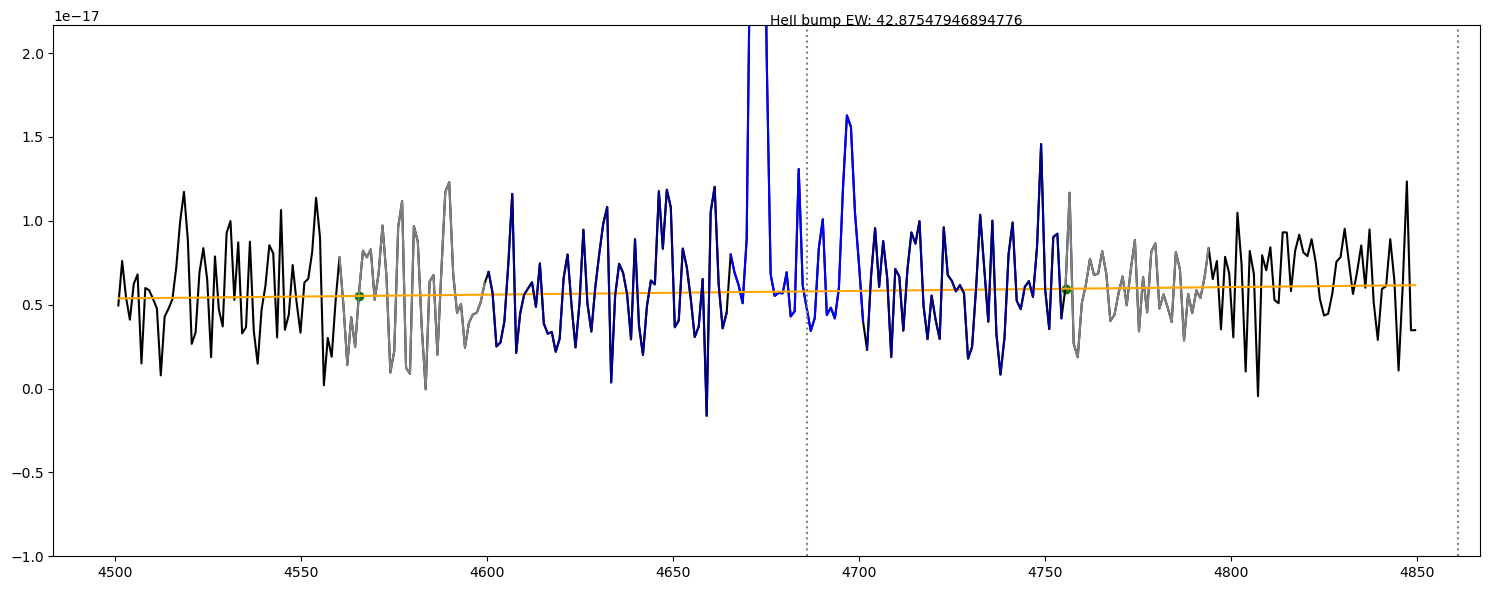

1
(4620,)


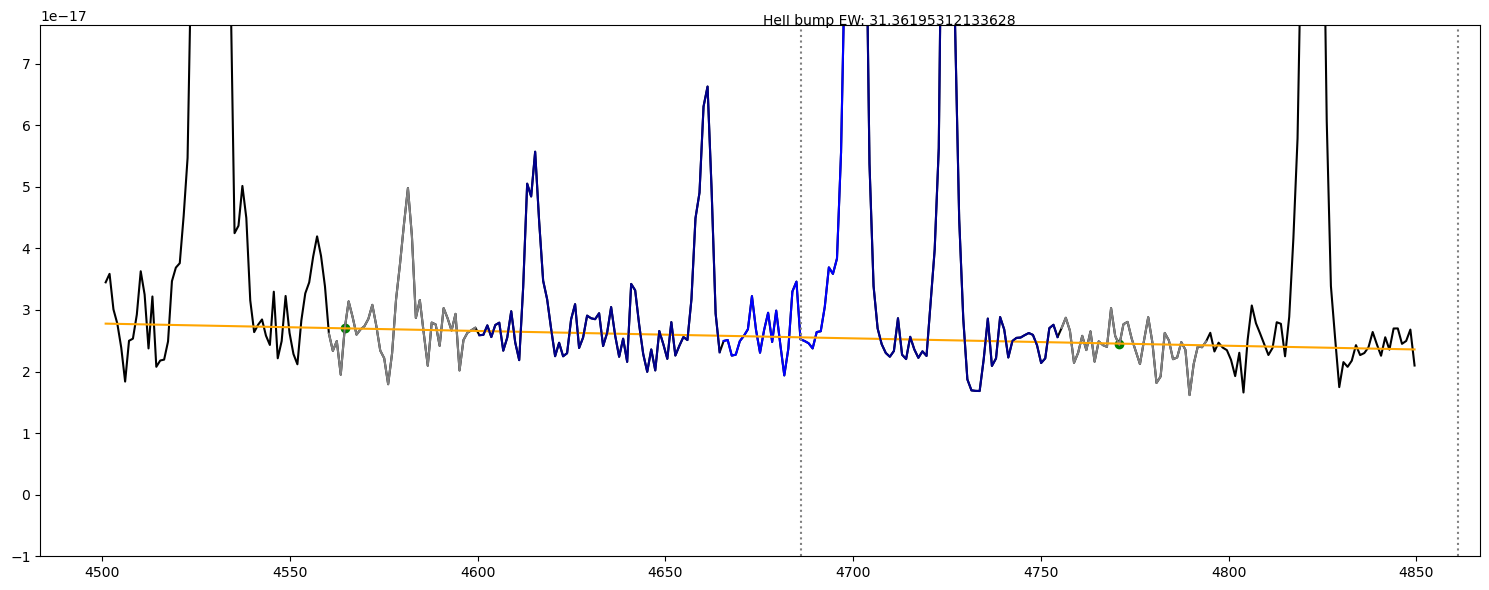

2
(4614,)


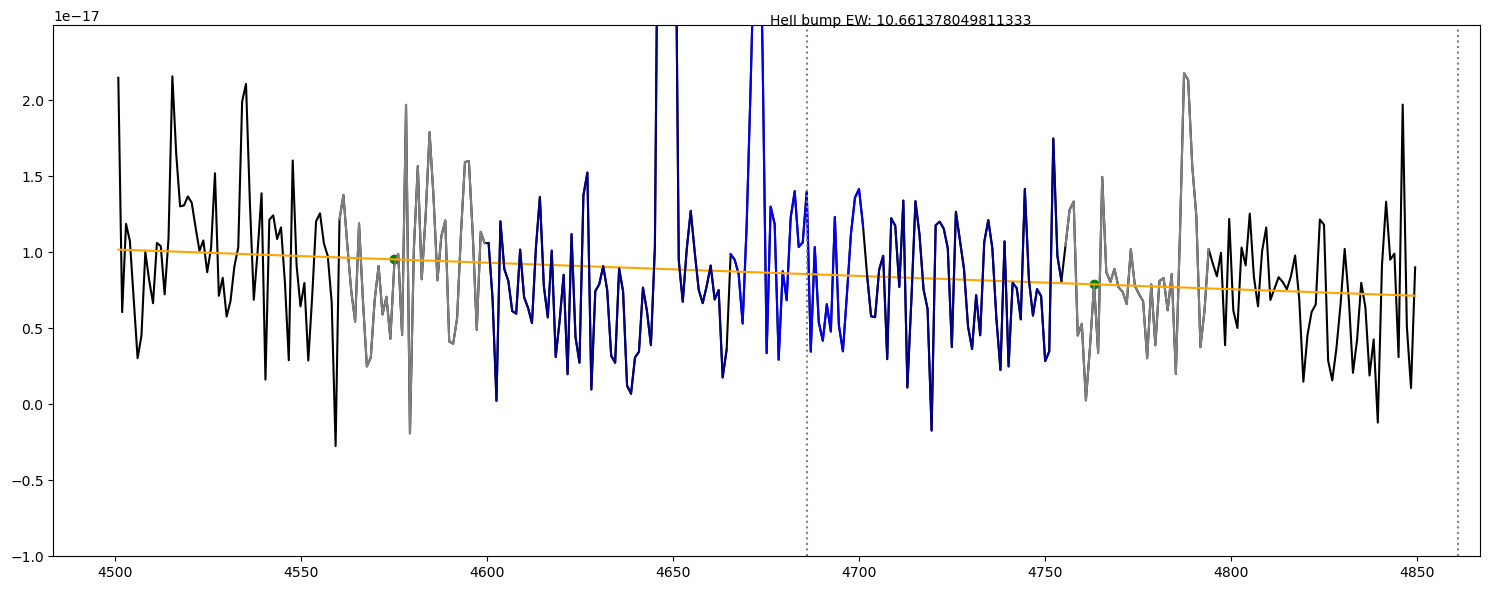

3
(4609,)


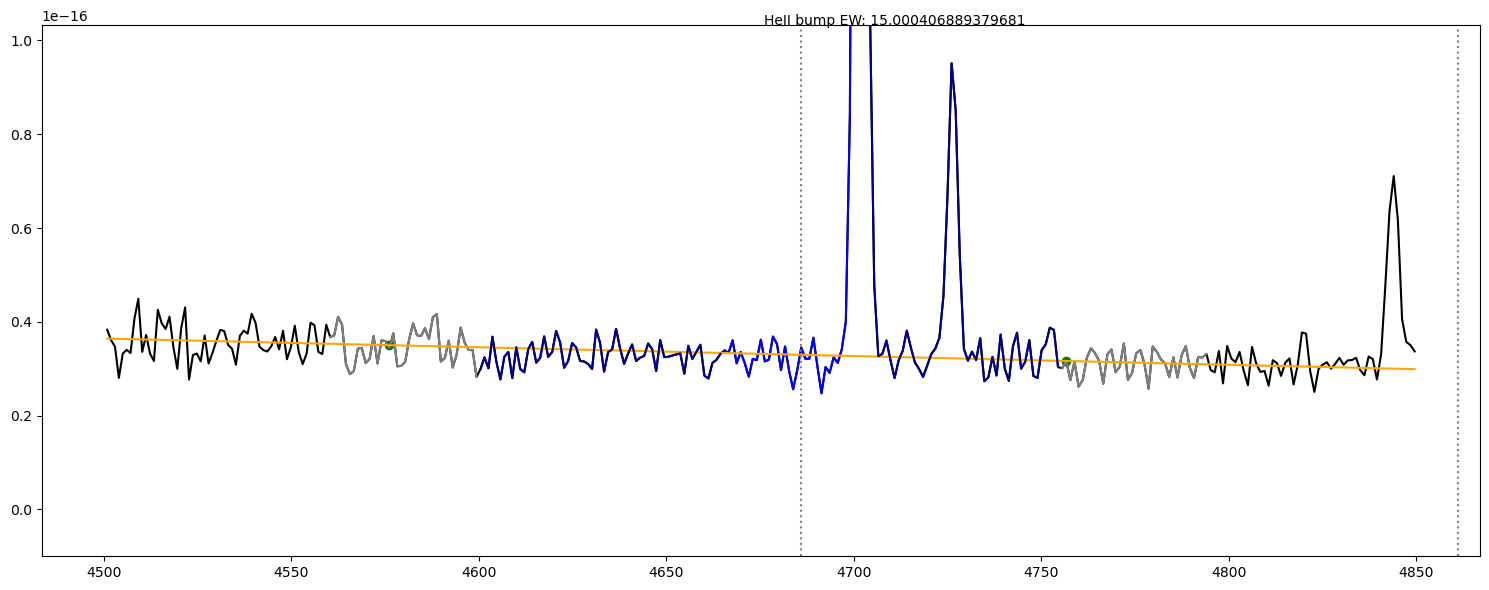

4
(4607,)


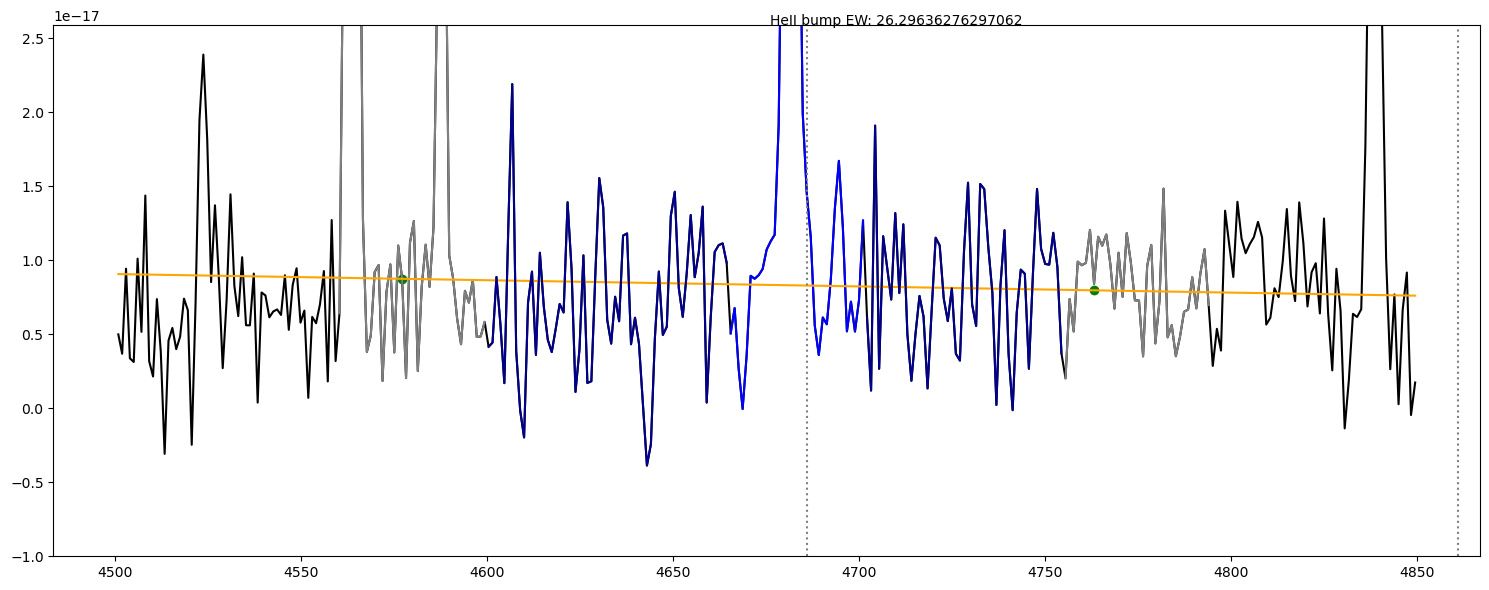

5
(4617,)


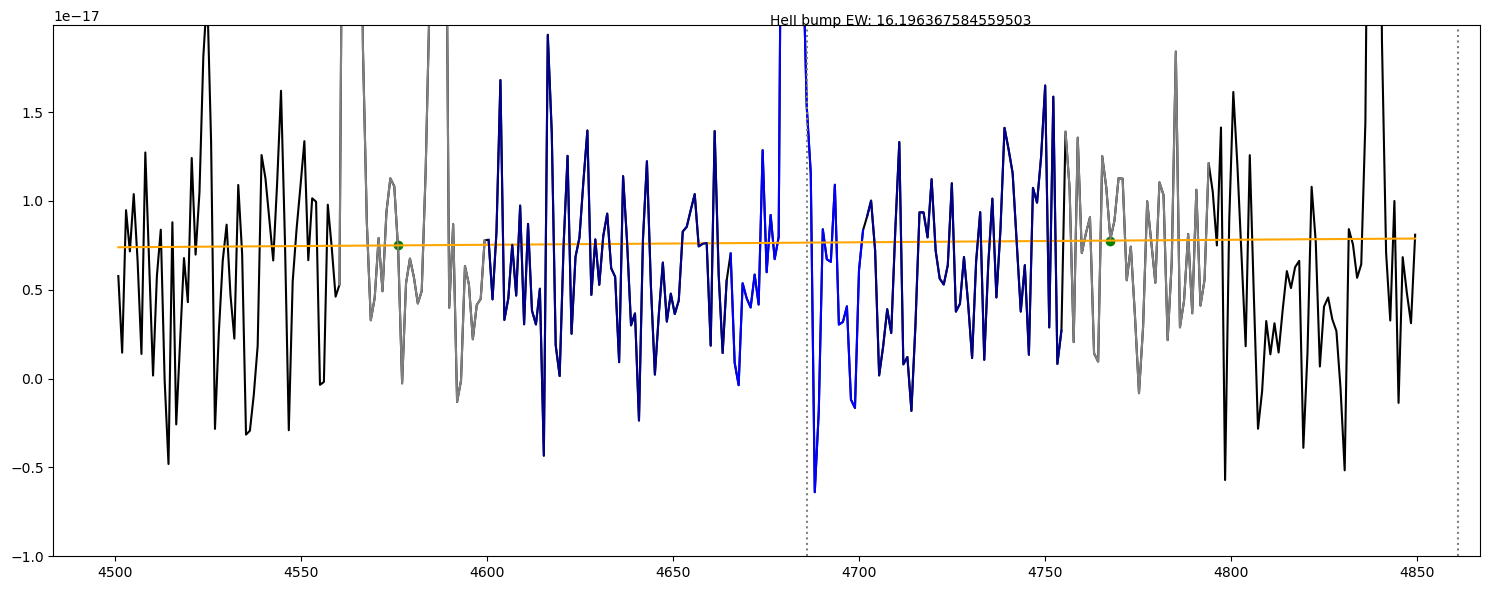

6
(4612,)


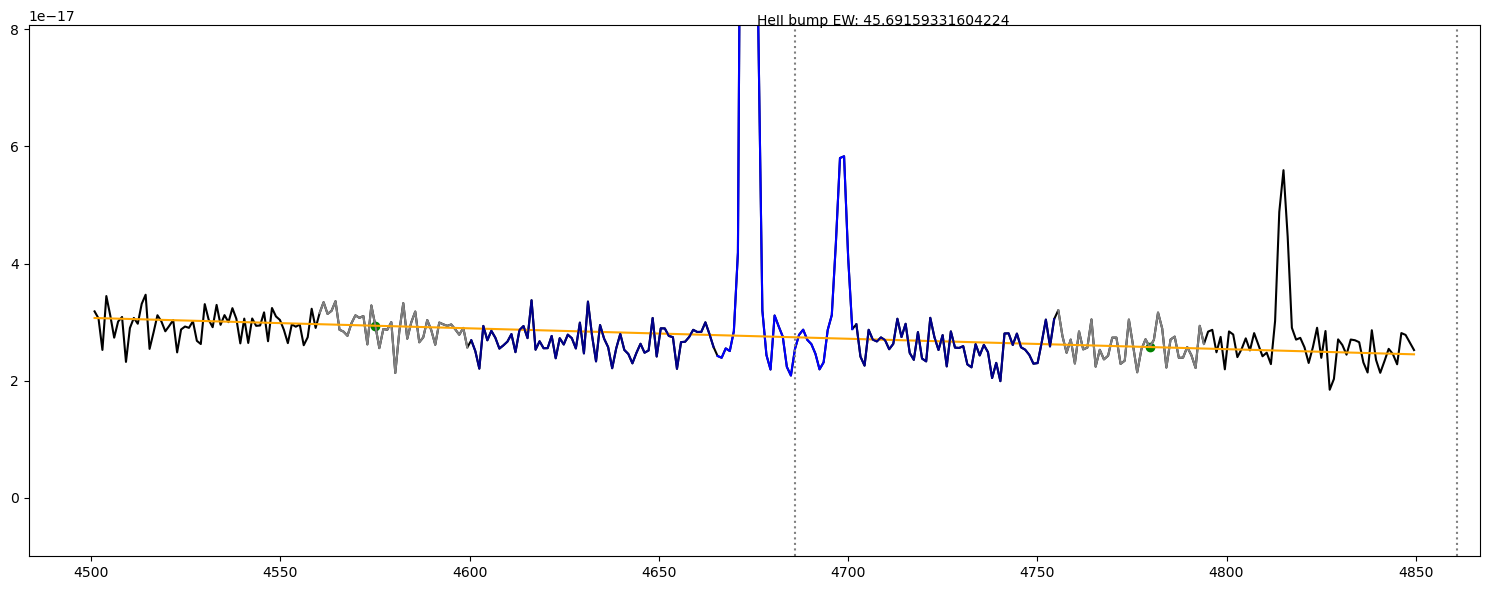

7
(4620,)


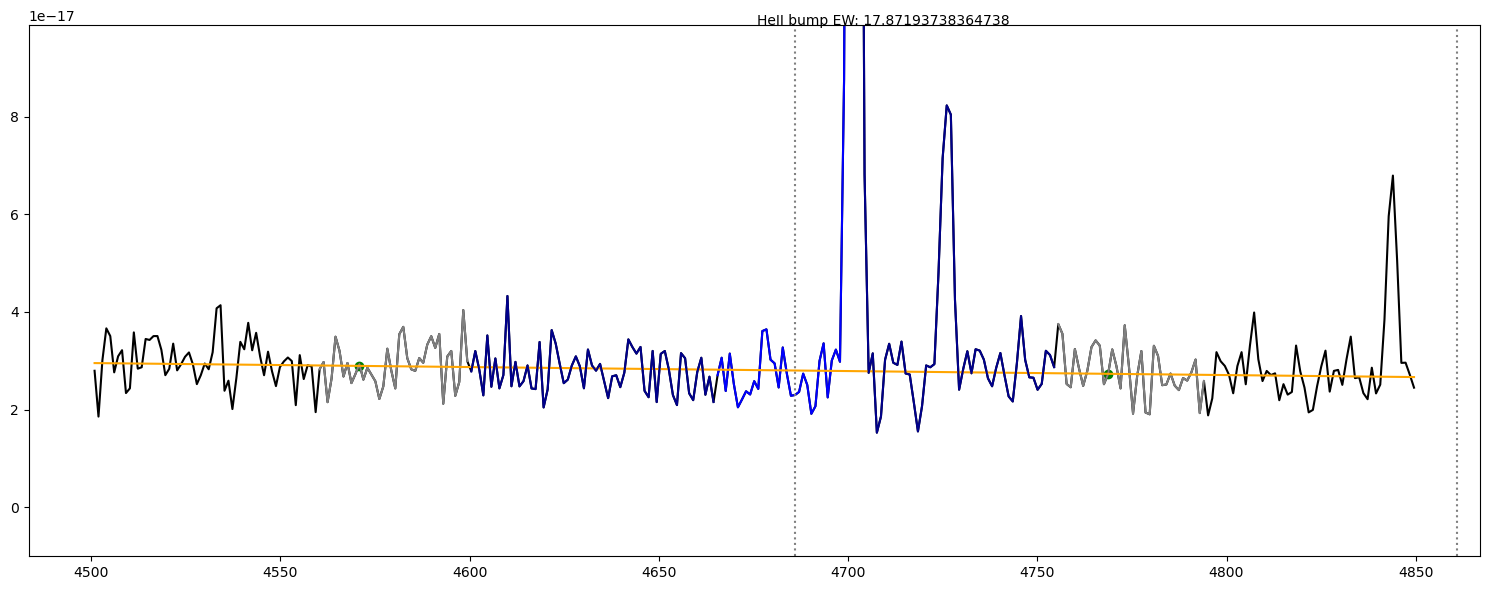

8
(4636,)


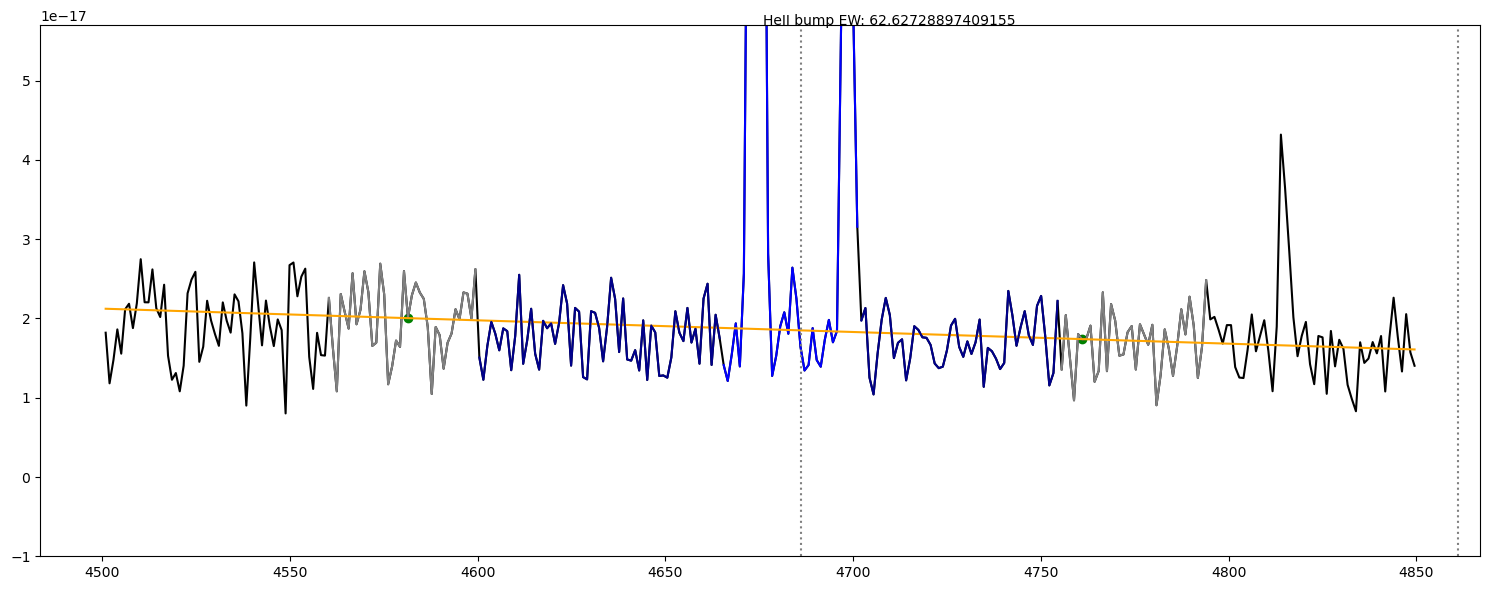

9
(4637,)


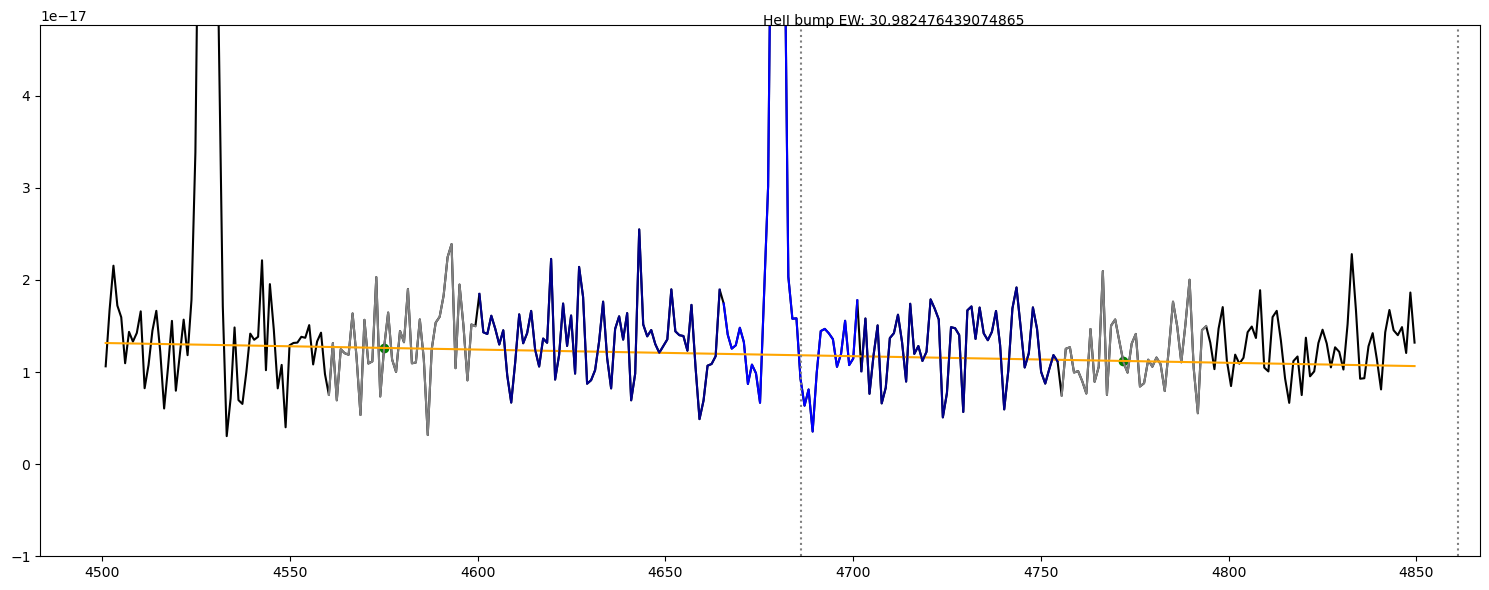

10
(4622,)


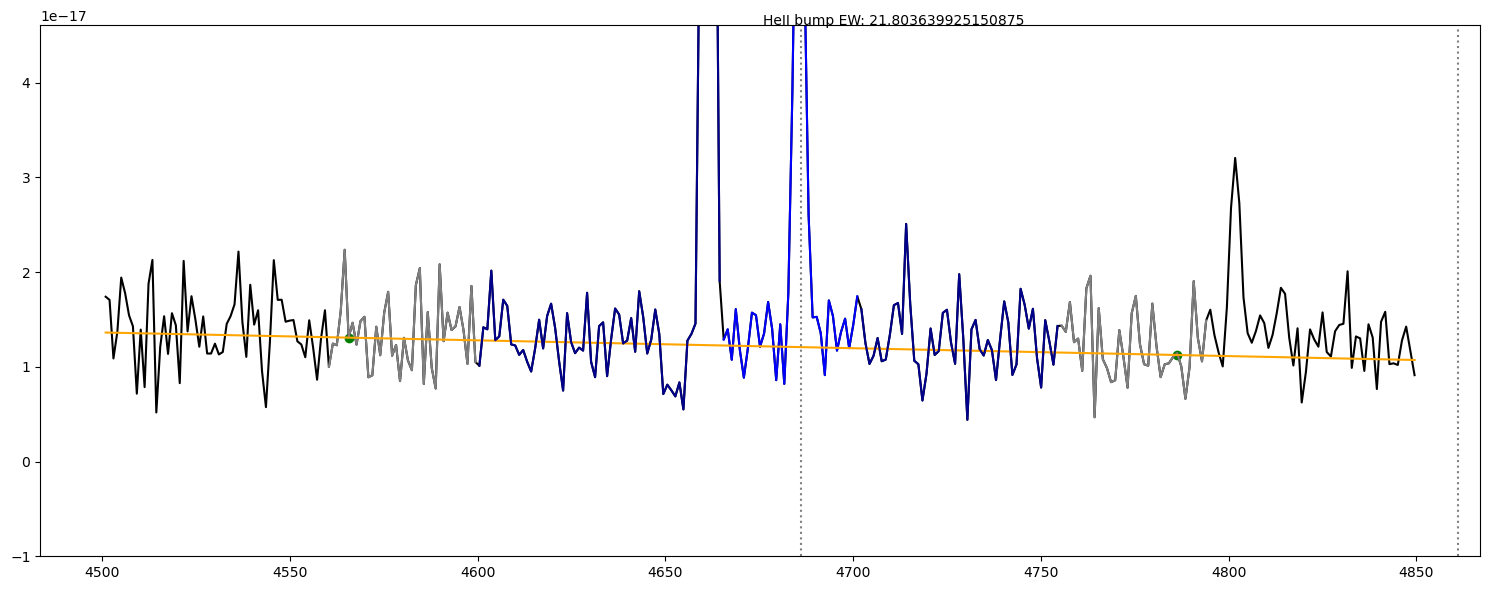

11
(4611,)


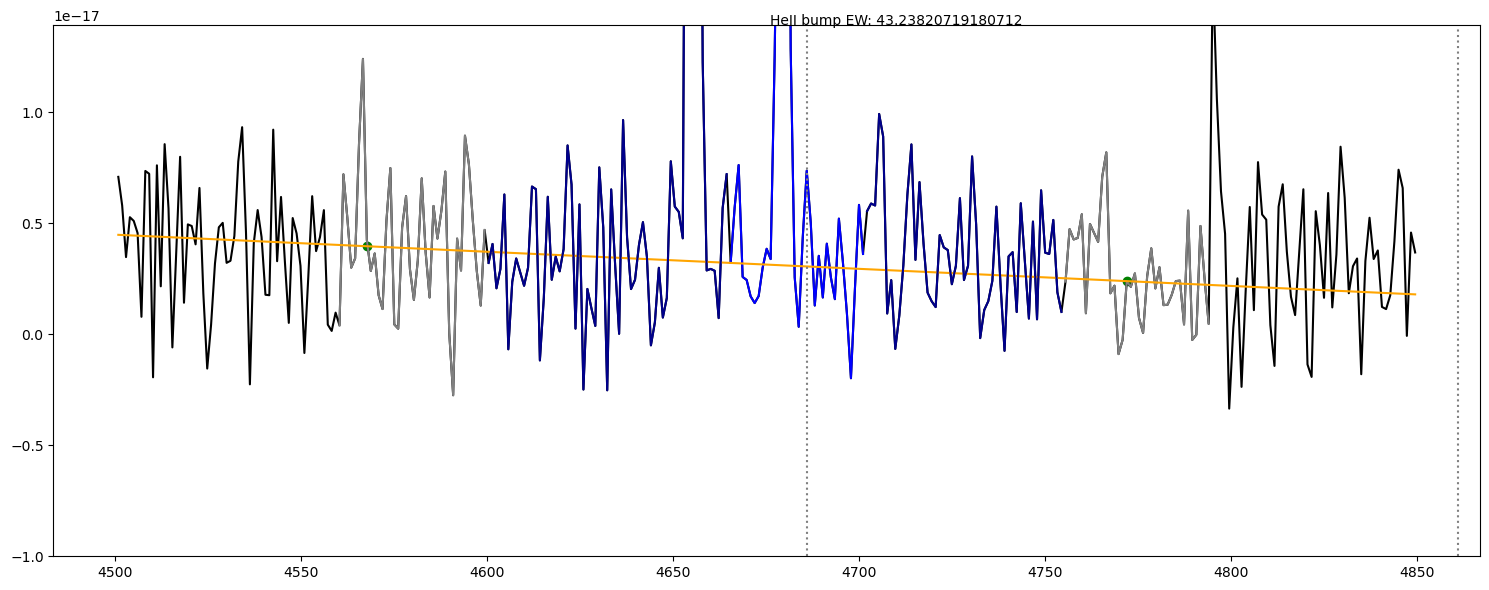

12
(4613,)


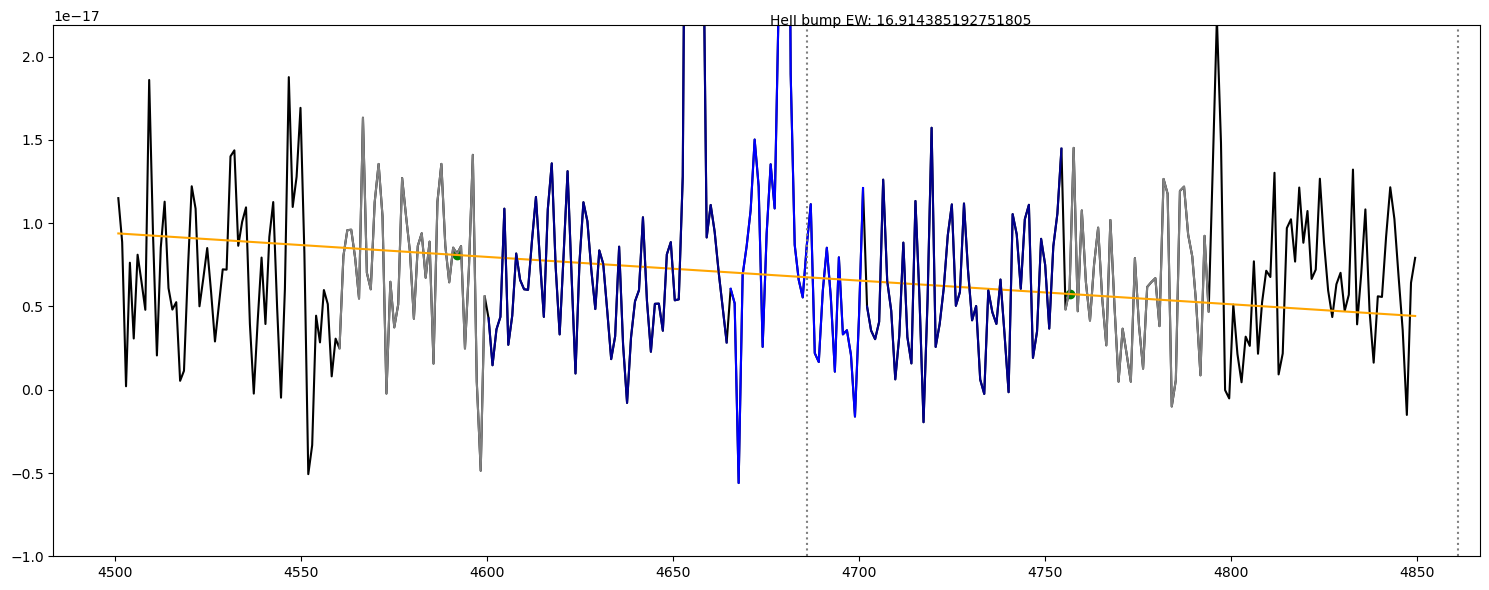

13
(4616,)


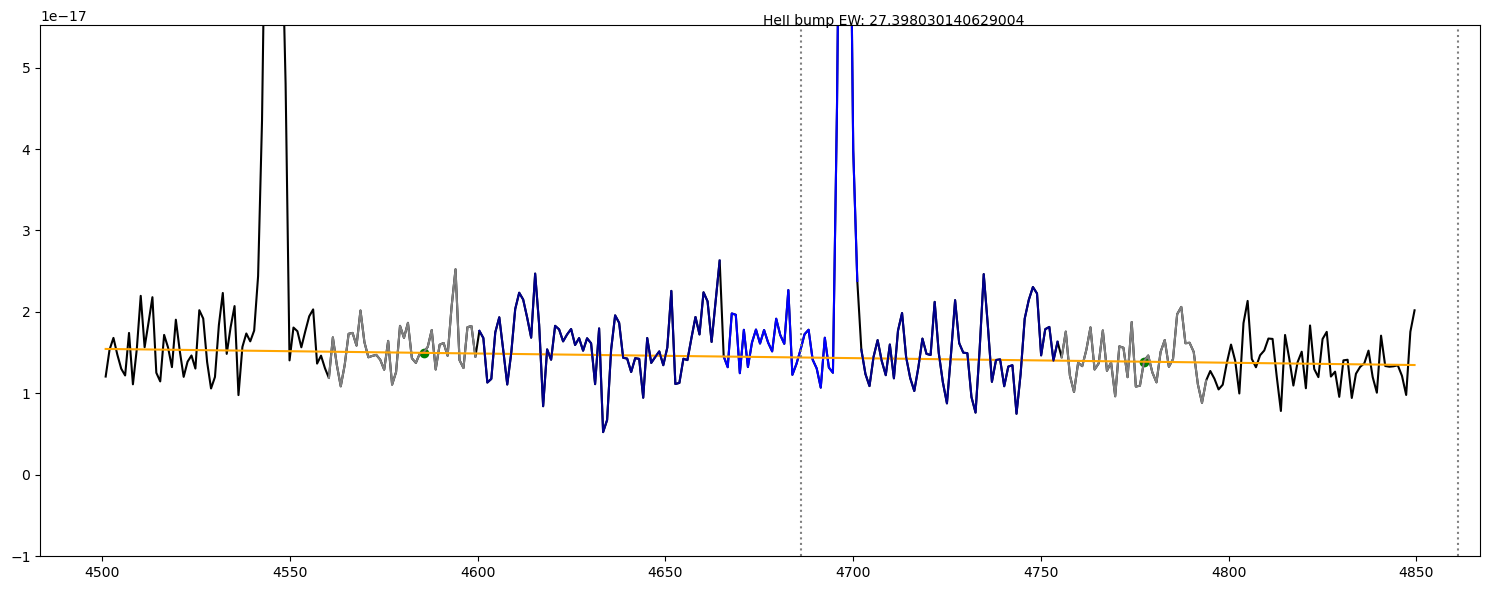

14
(4622,)


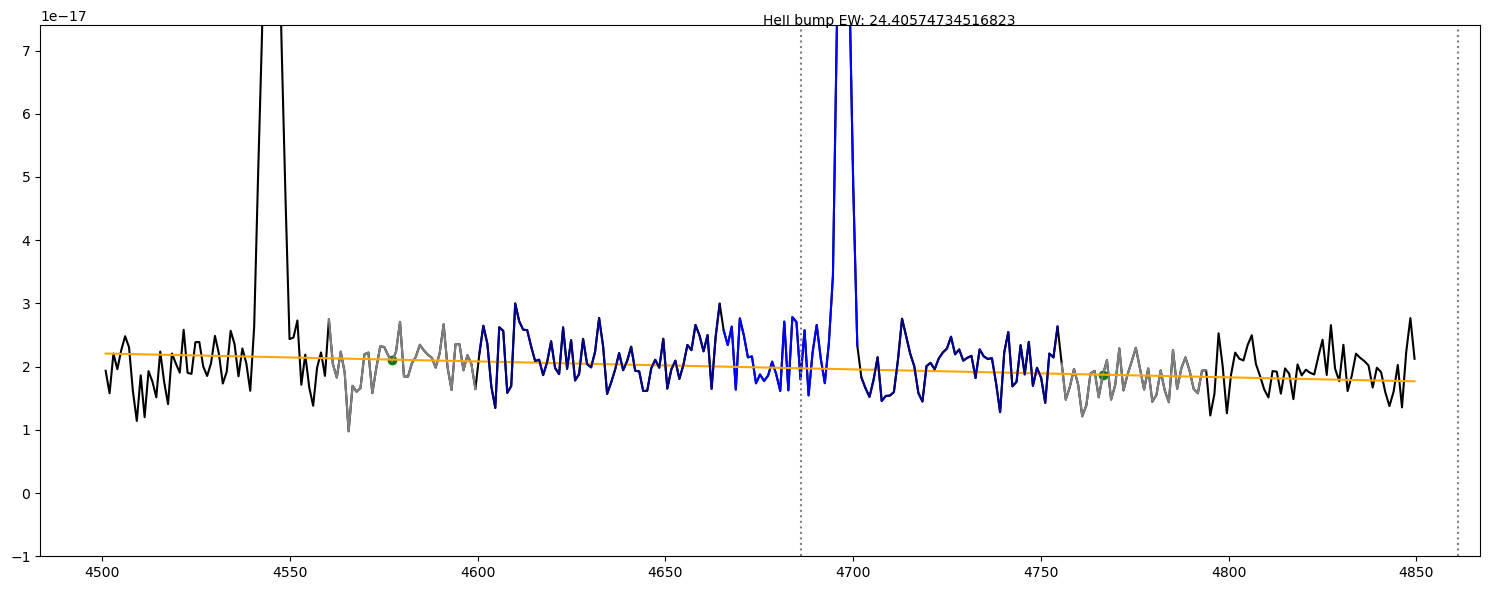

15
(4620,)


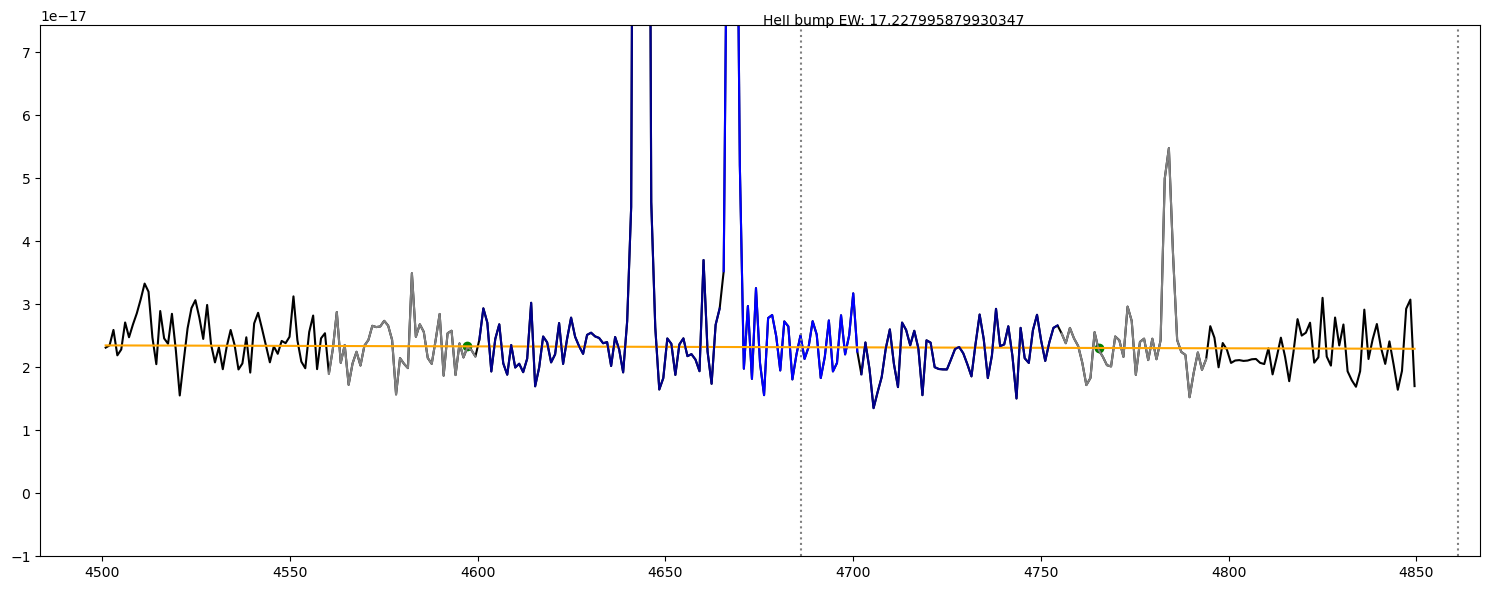

16
(4616,)


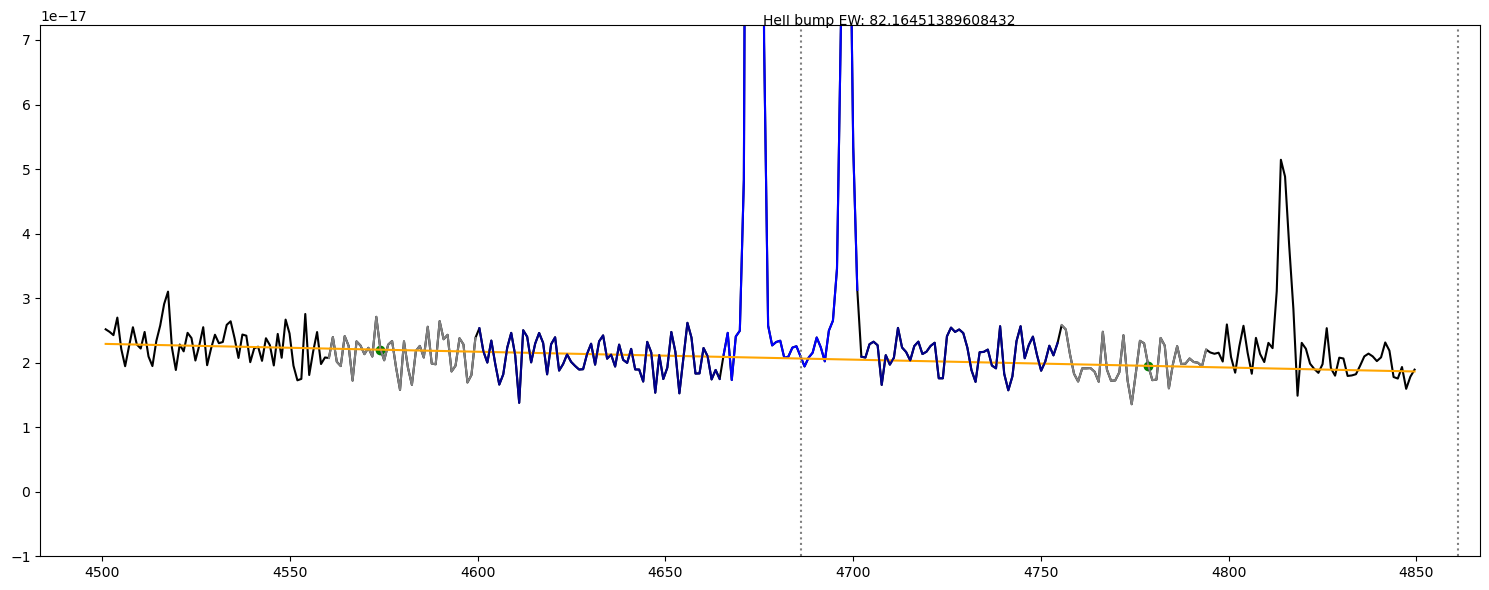

17
(4638,)


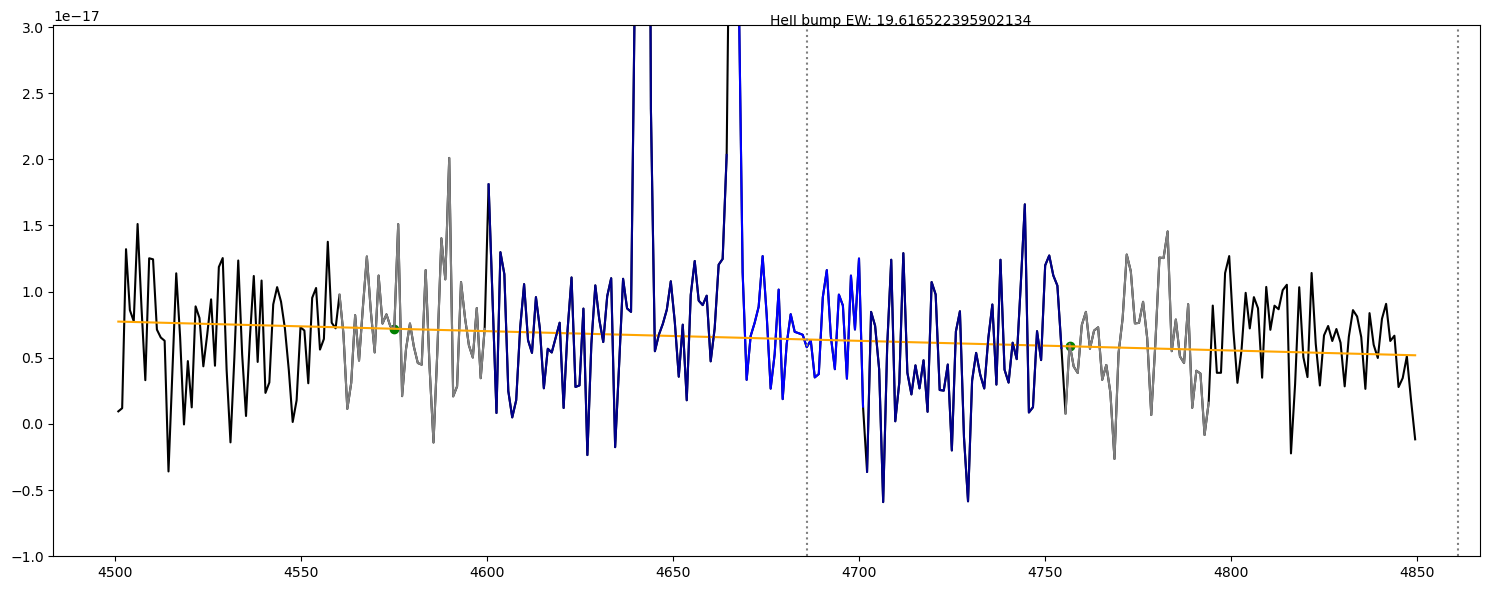

18
(4616,)


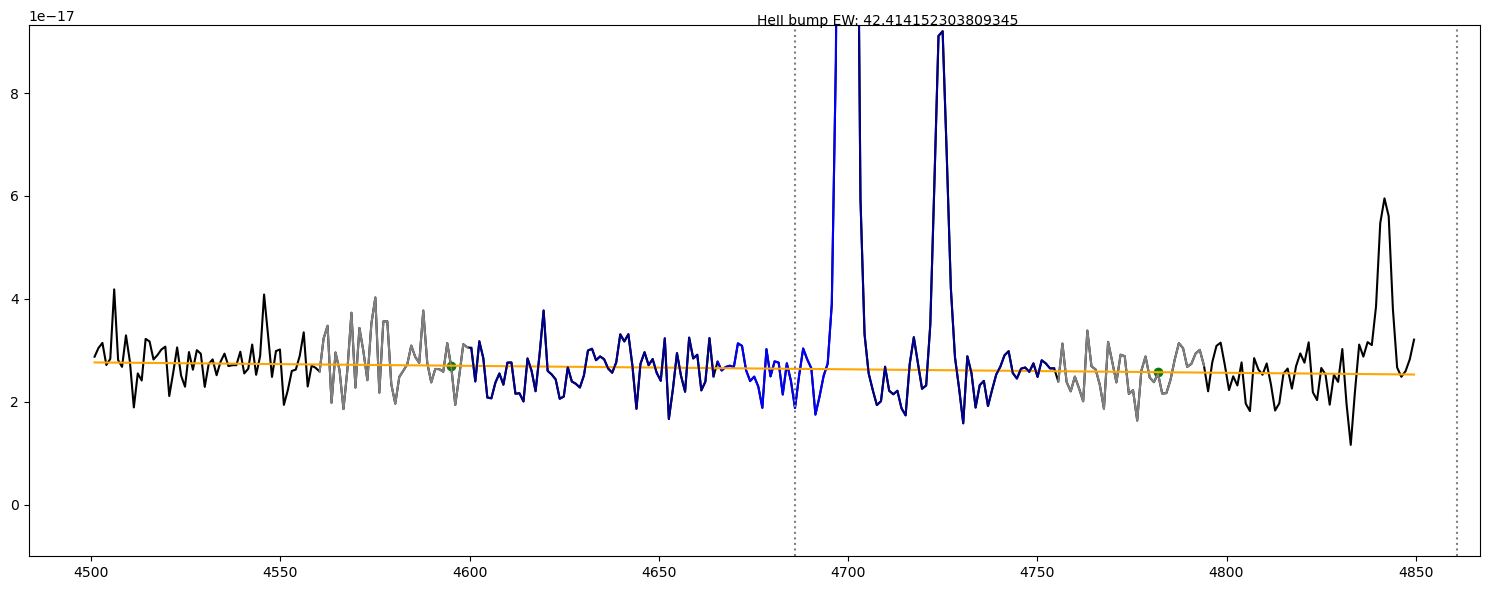

19
(4630,)


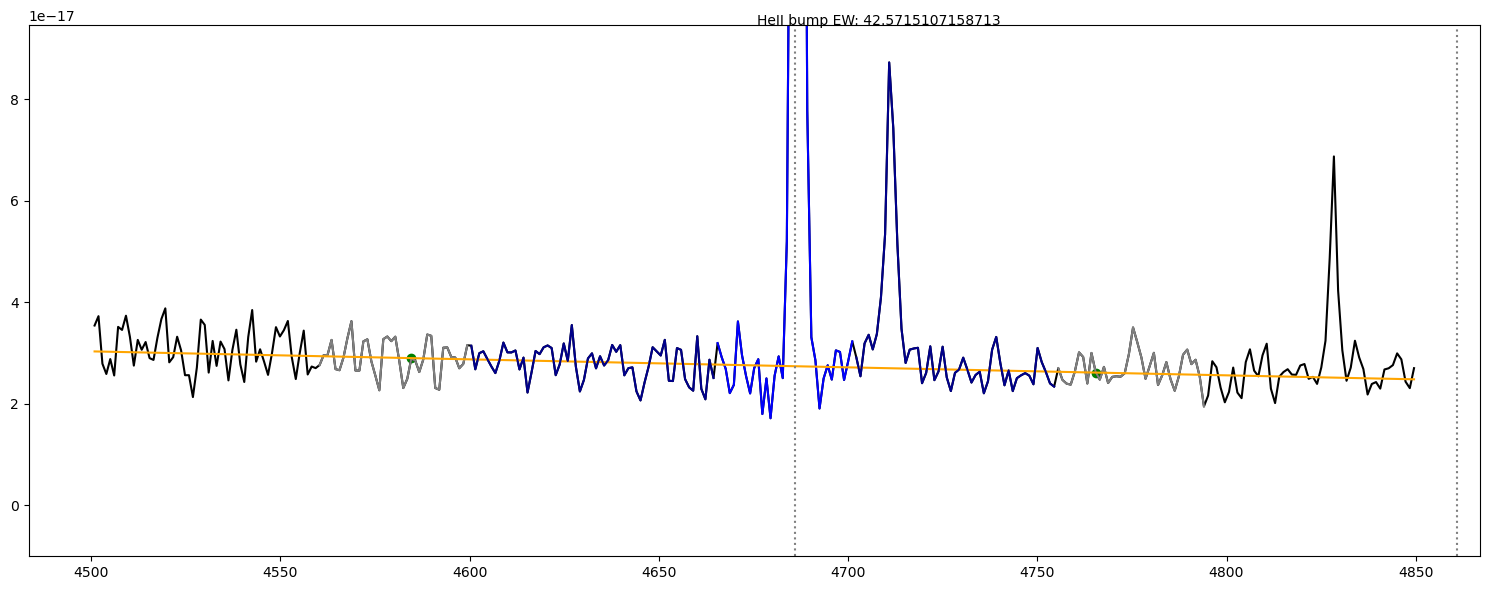

20
(4616,)


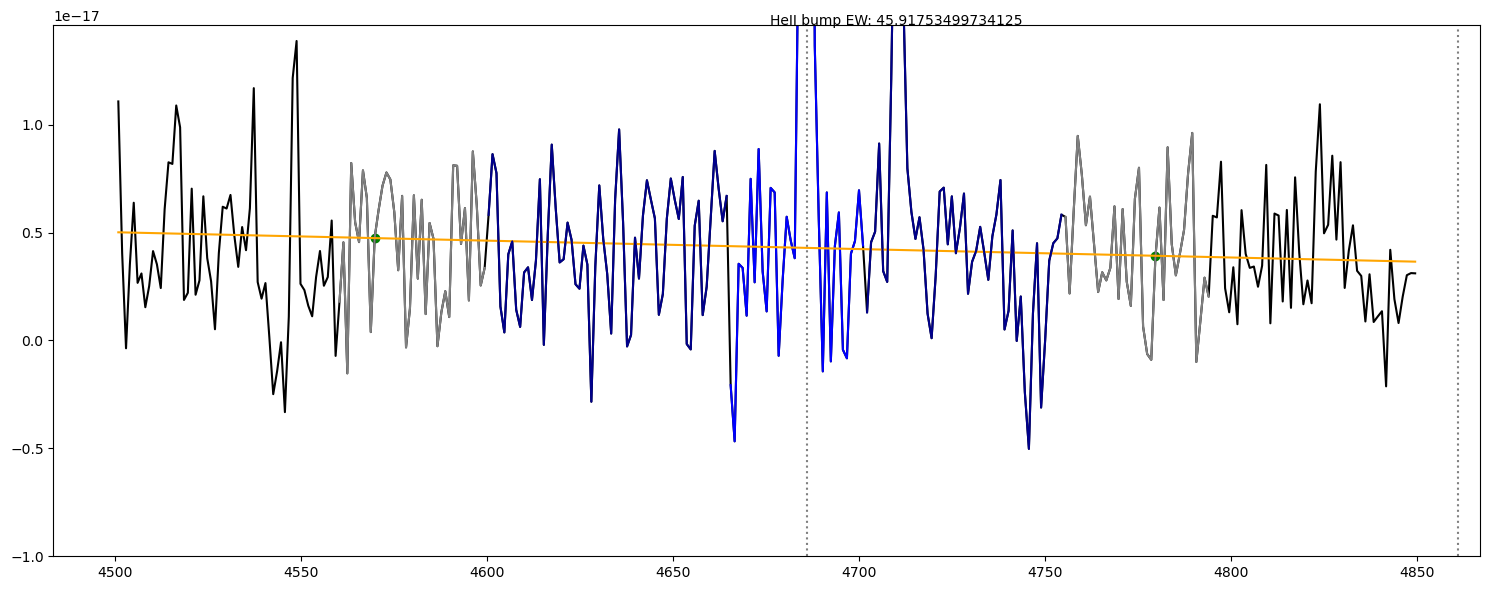

21
(4618,)


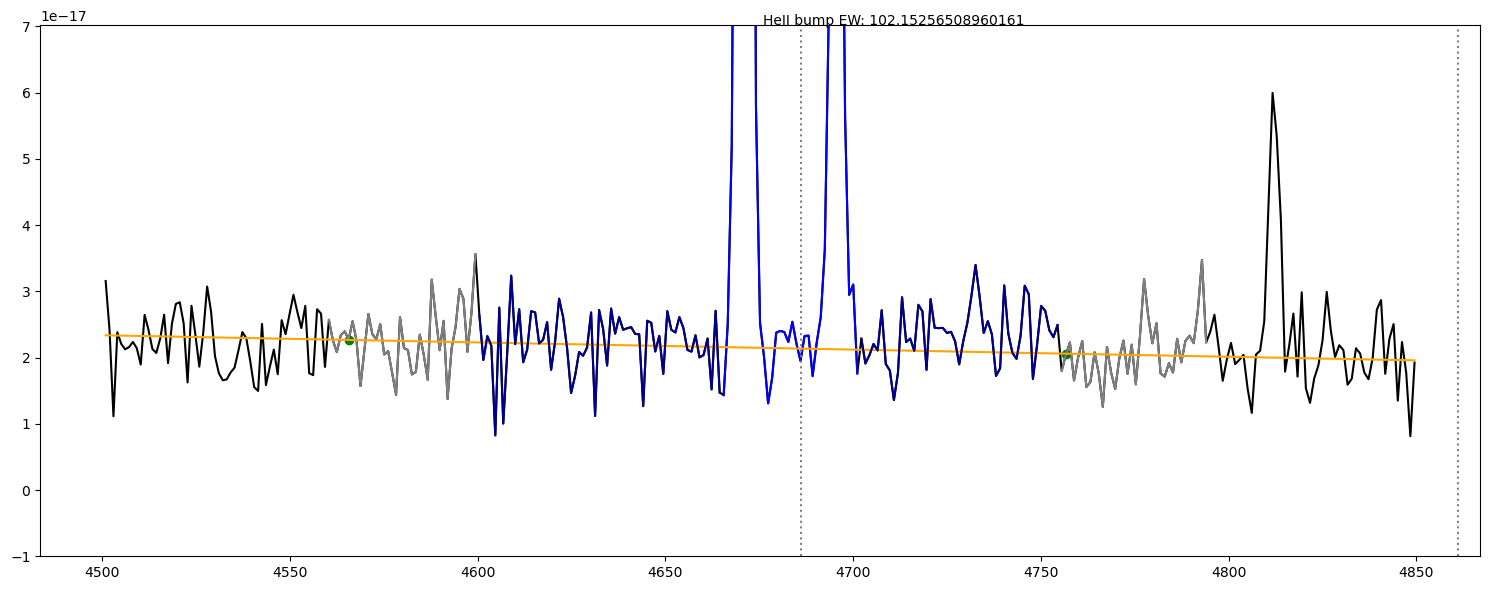

22
(4641,)


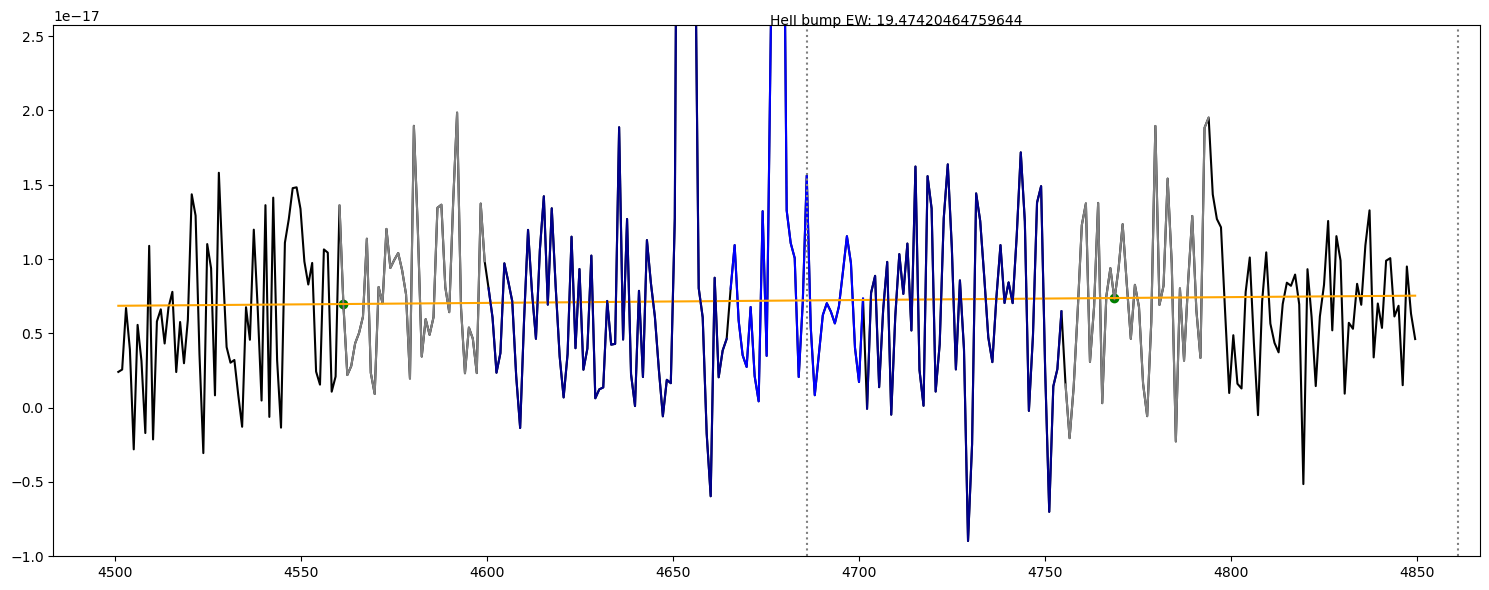

23
(4636,)


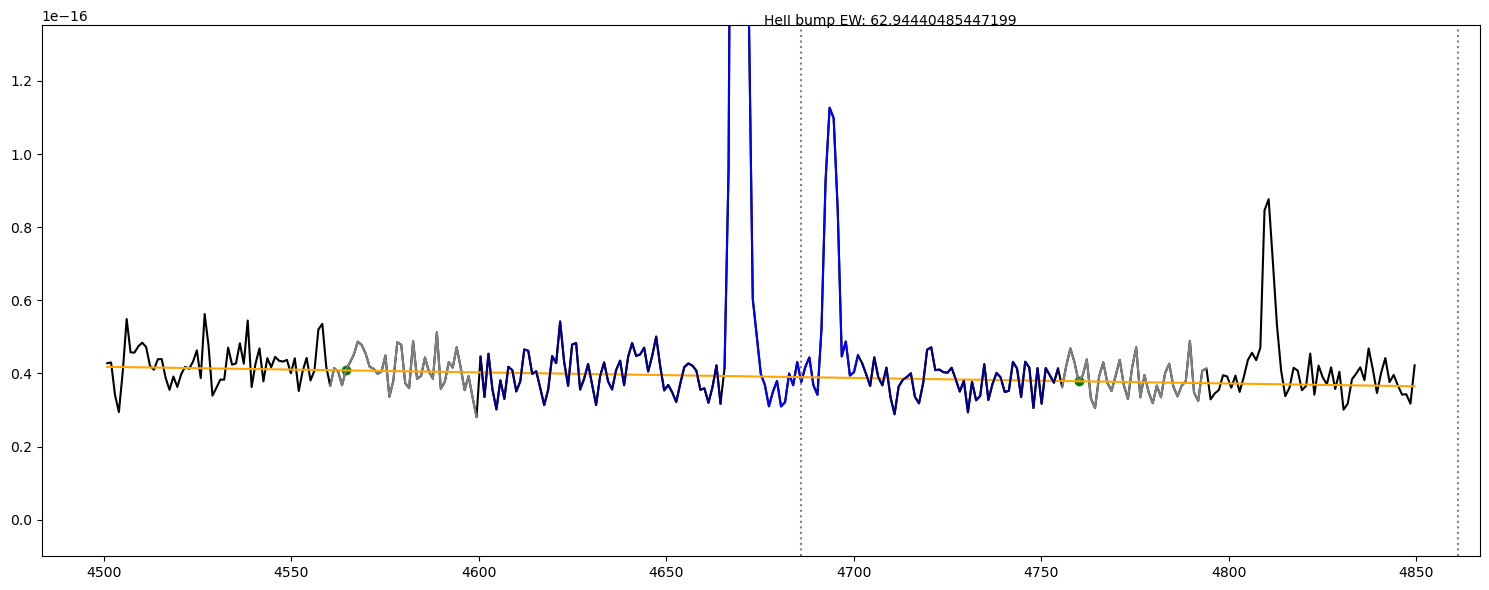

24
(4615,)


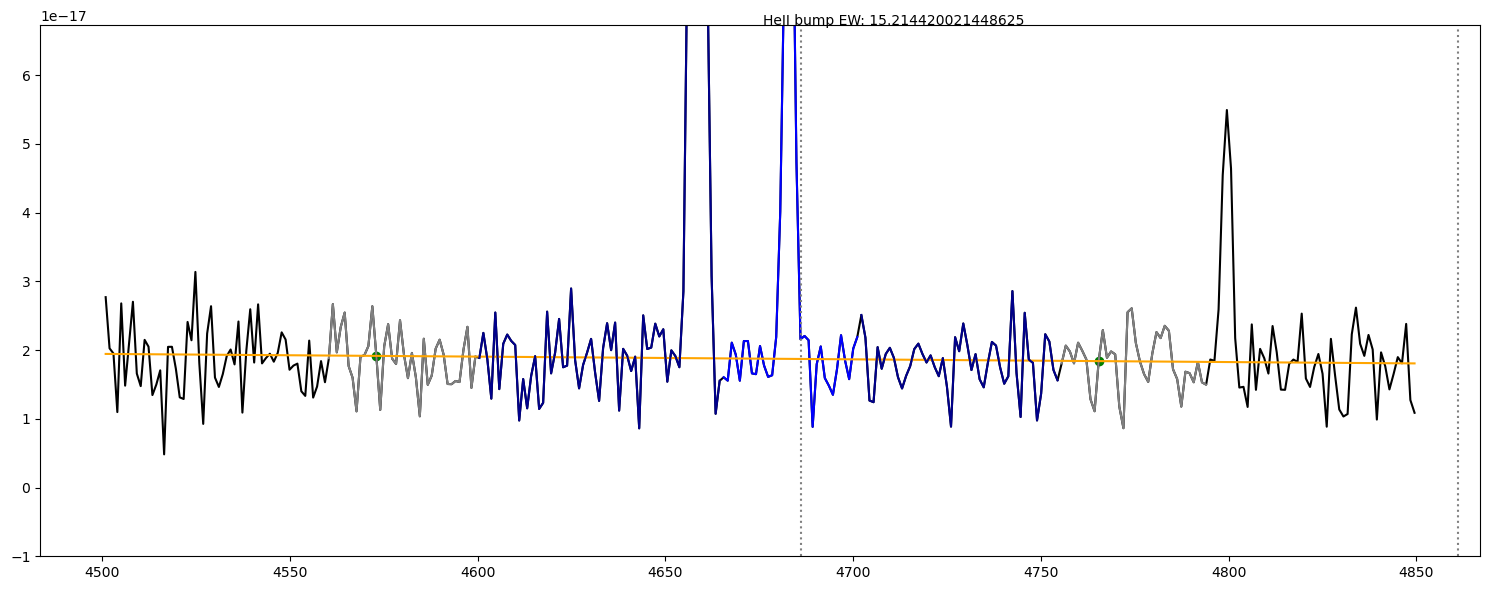

25
(4601,)


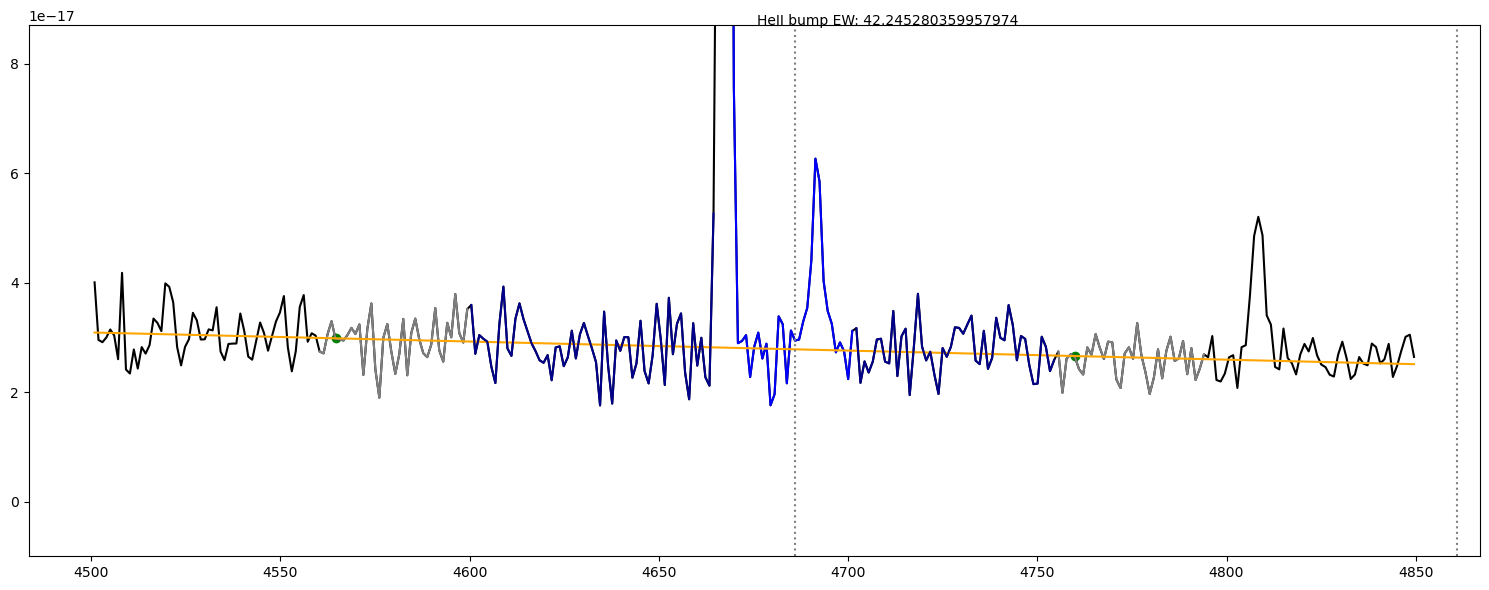

26
(4608,)


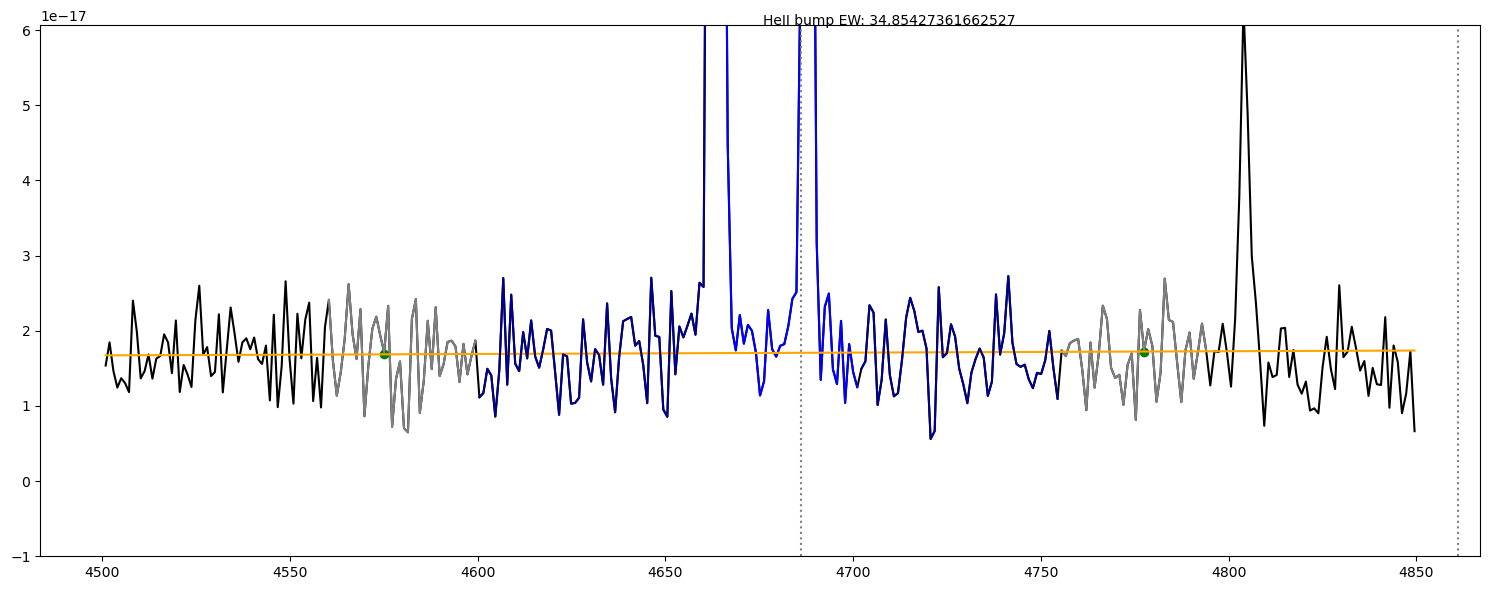

27
(4605,)


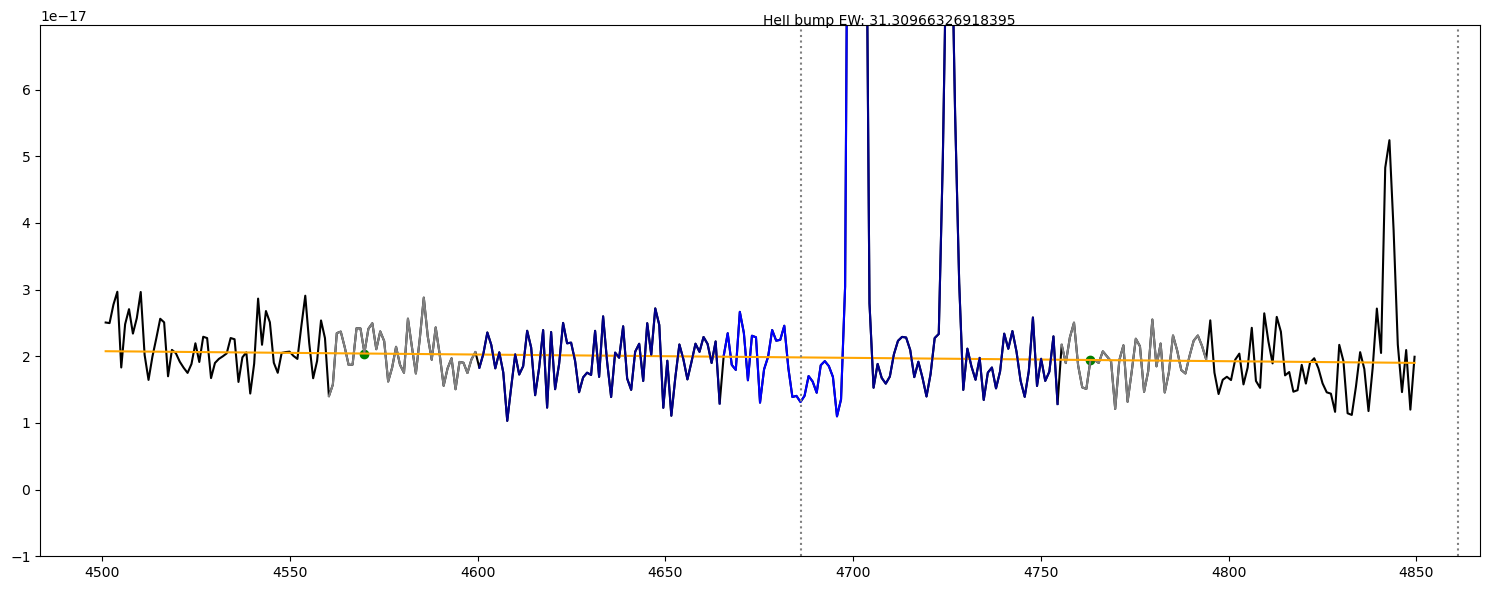

28
(4638,)


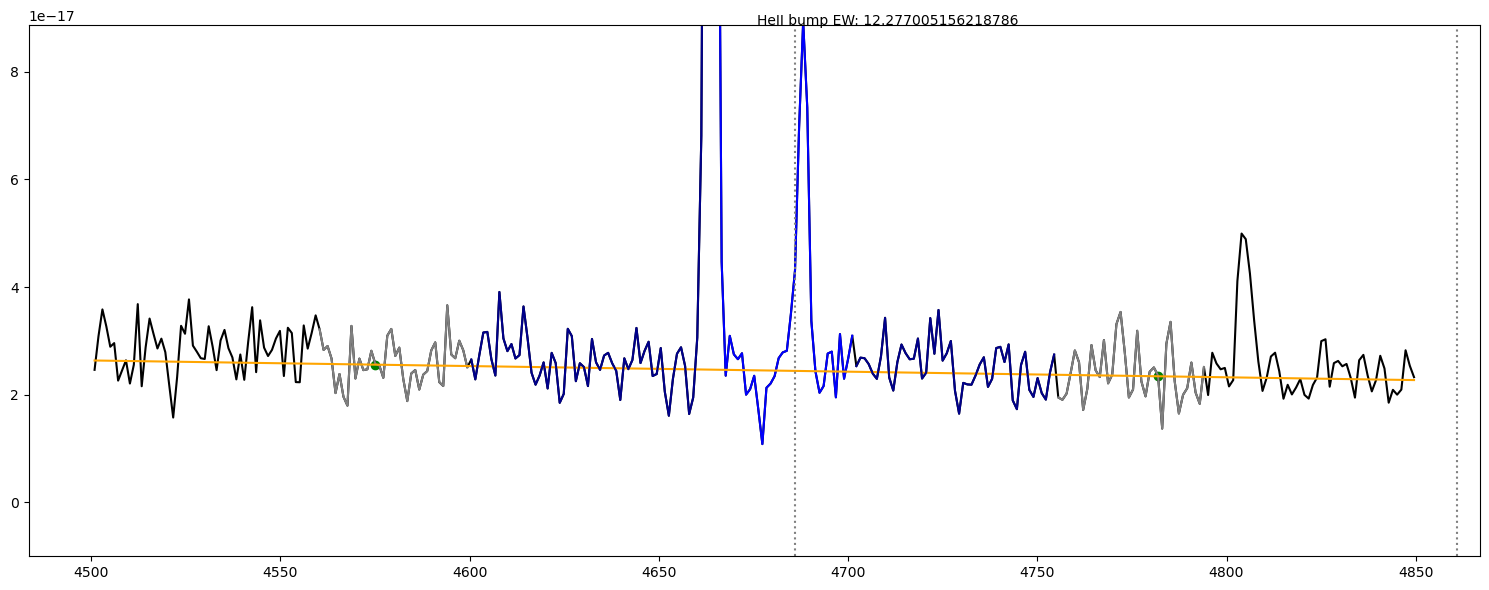

29
(4637,)


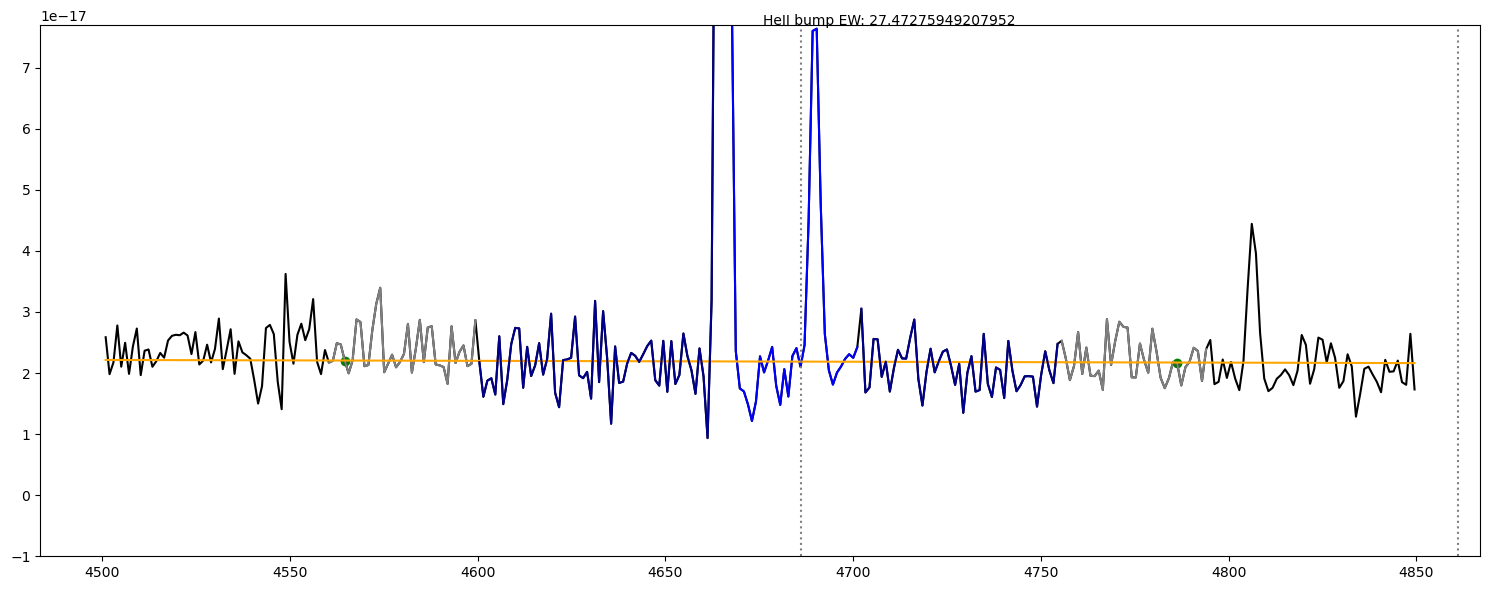

30
(4637,)


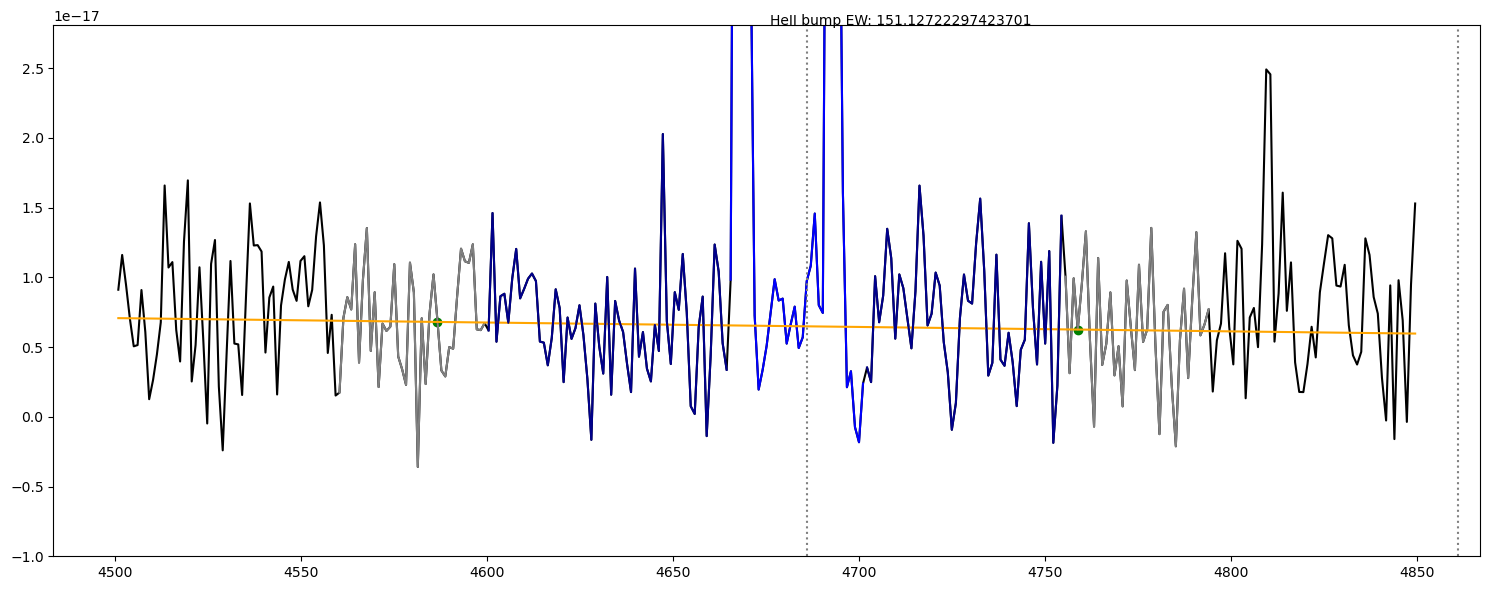

31
(4614,)


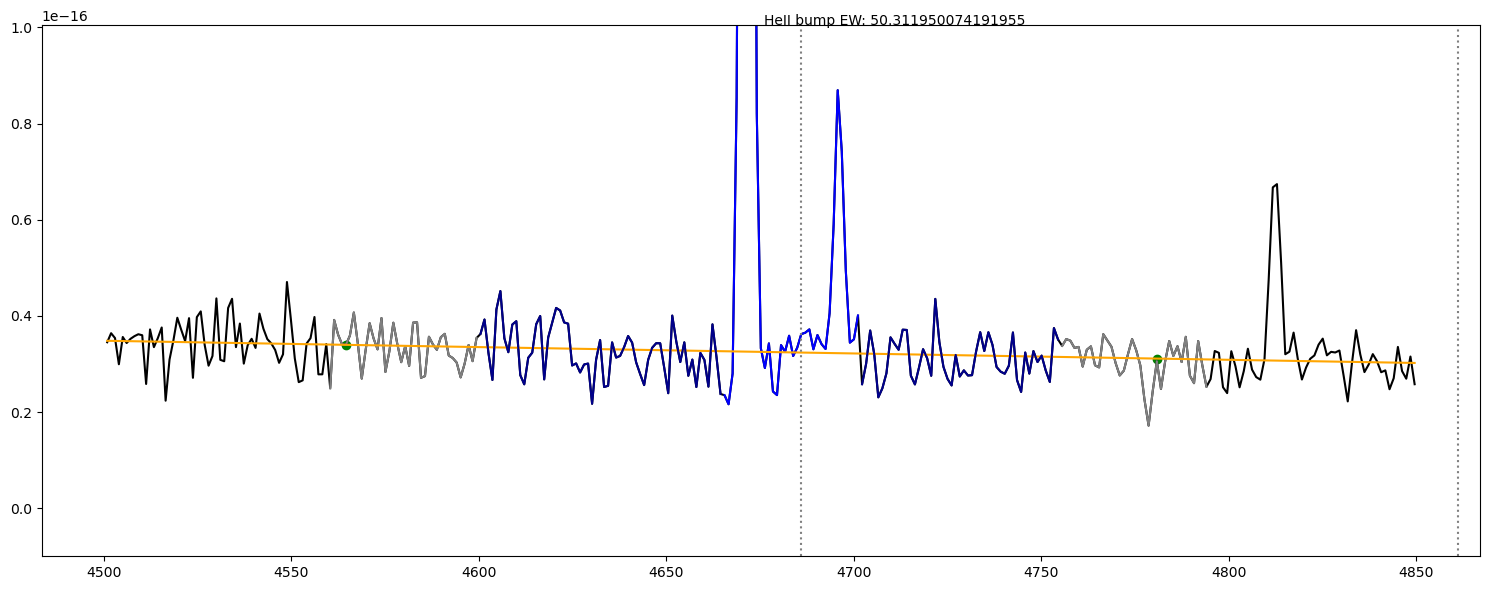

32
(4595,)


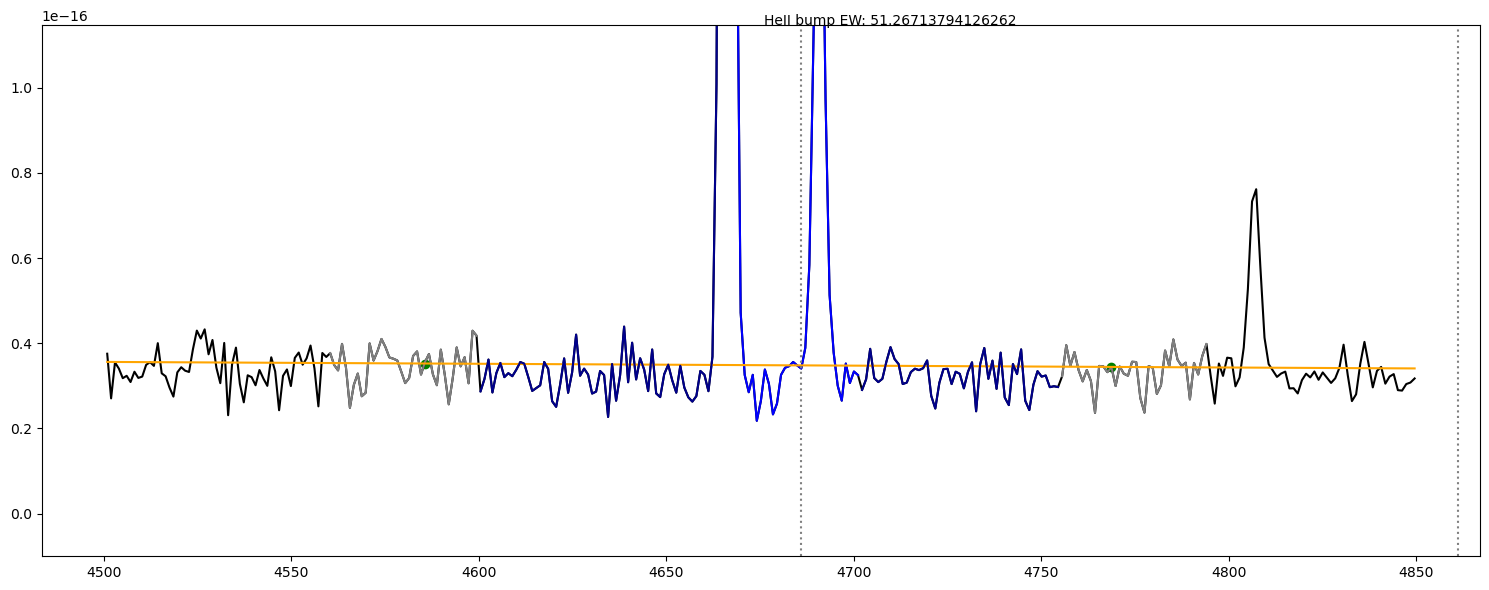

33
(4607,)


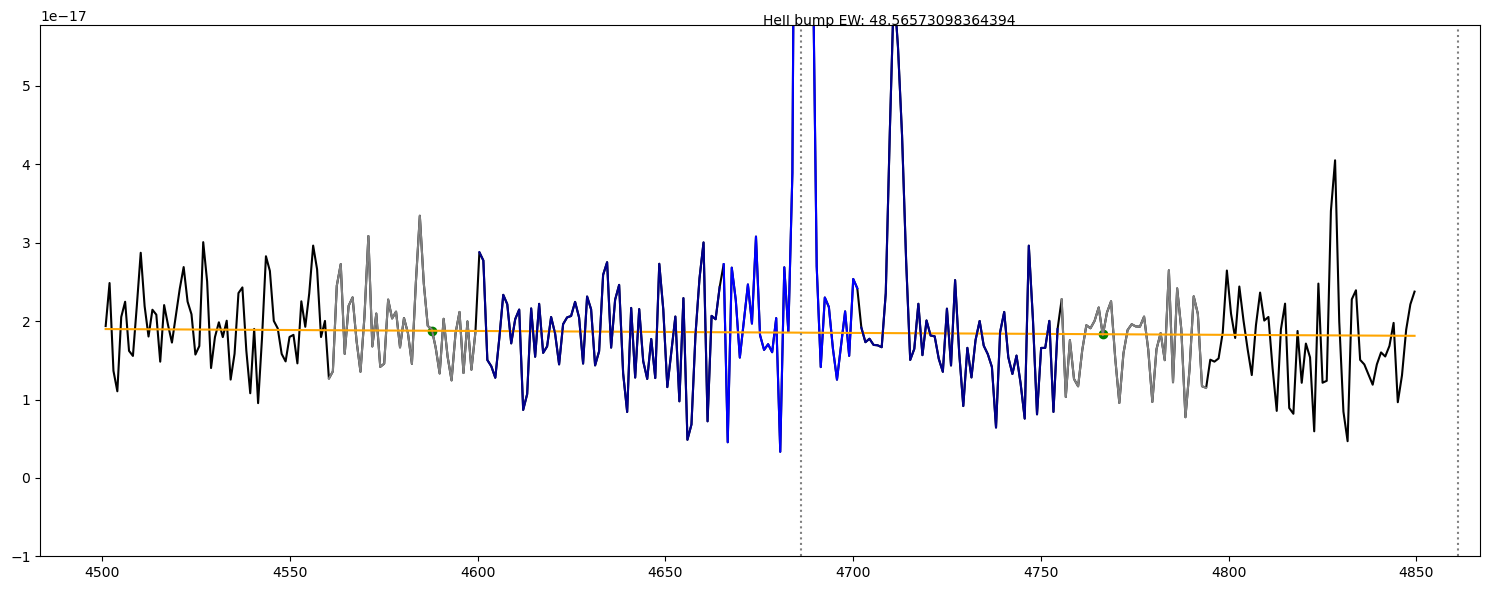

34
(4618,)


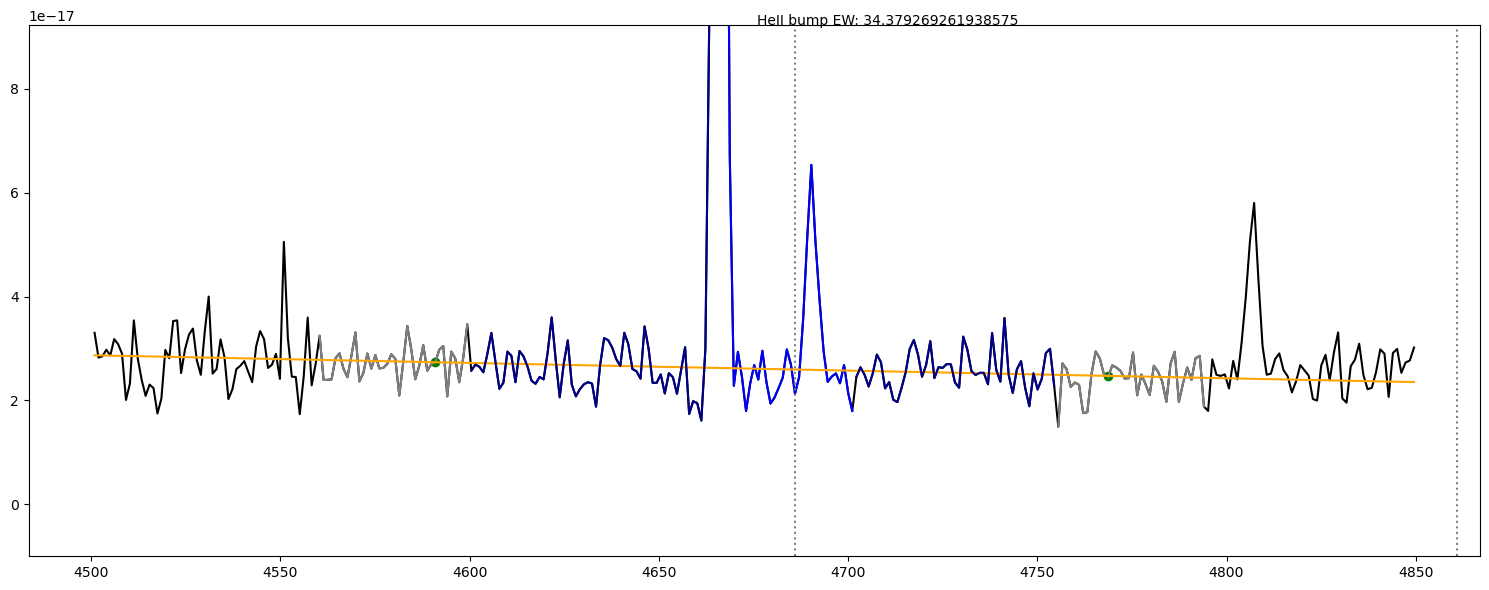

35
(4627,)


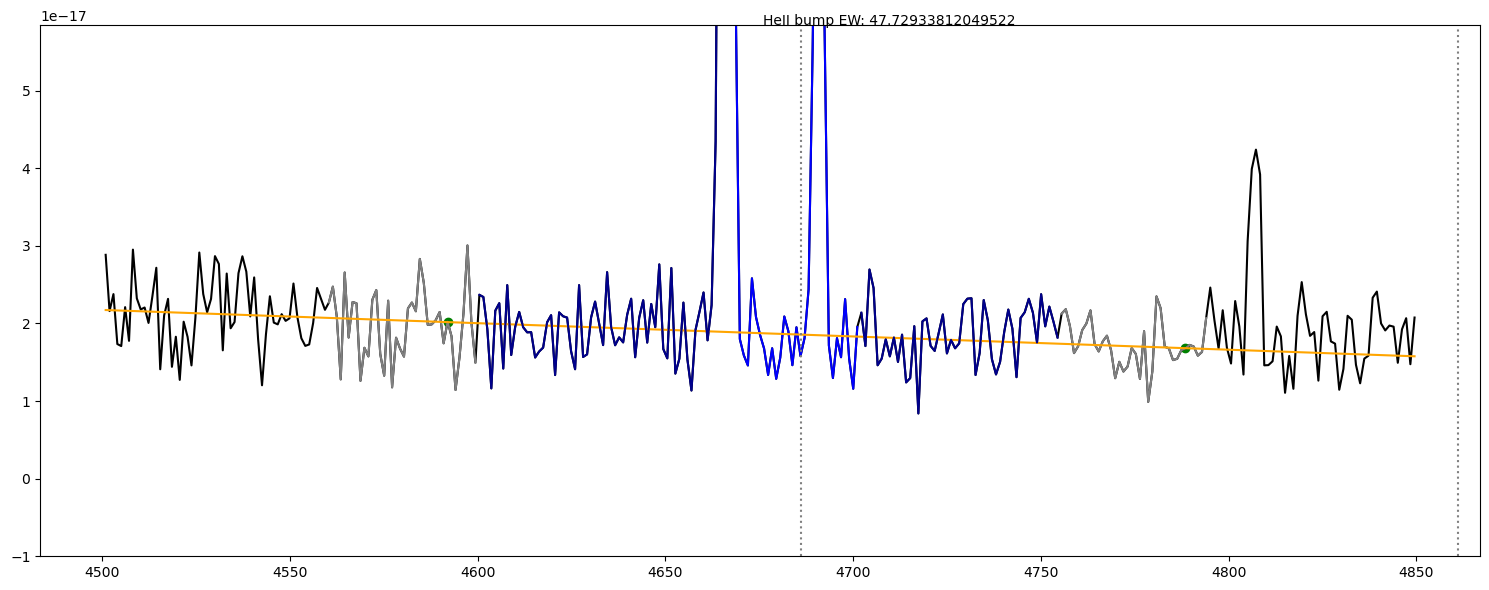

36
(4584,)


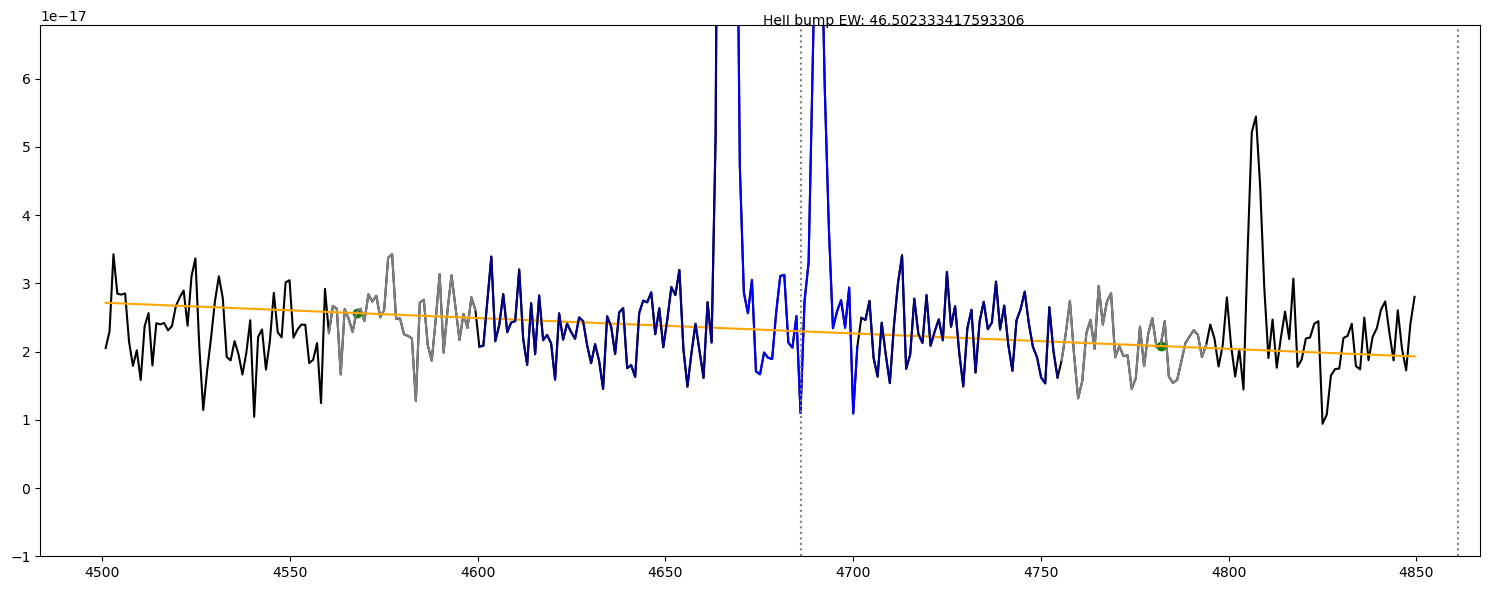

37
(4635,)


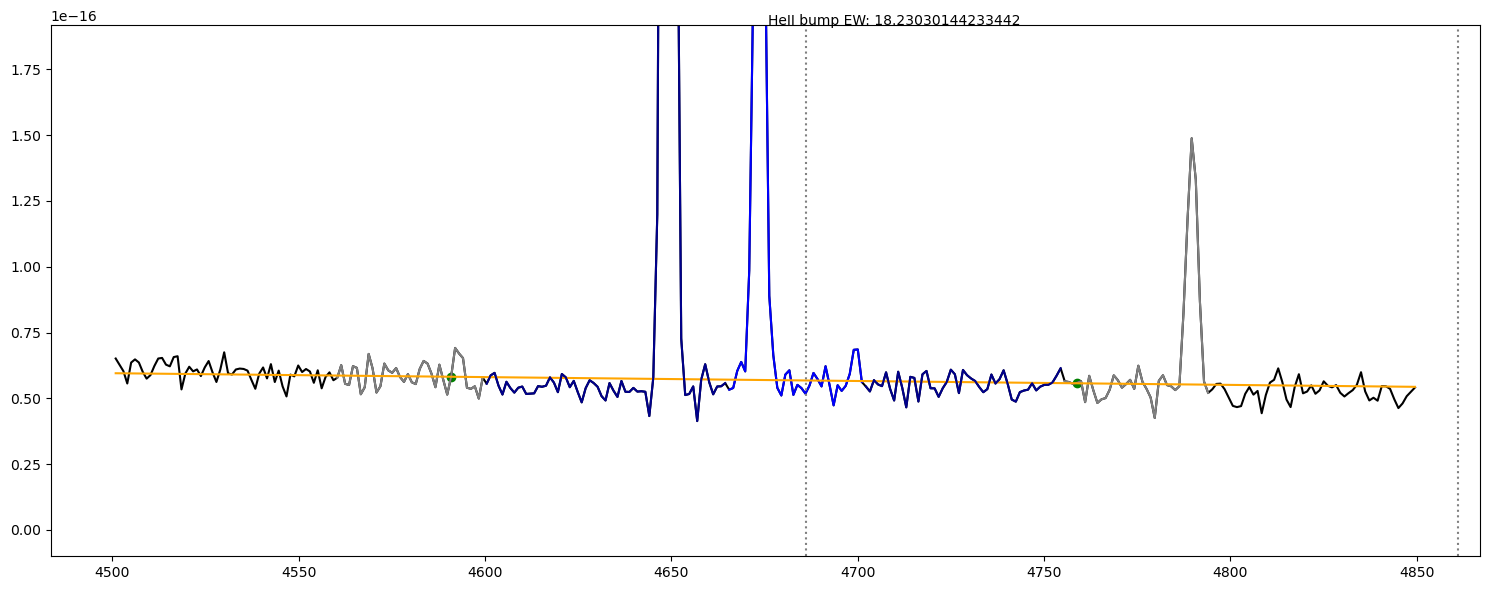

38
(4633,)


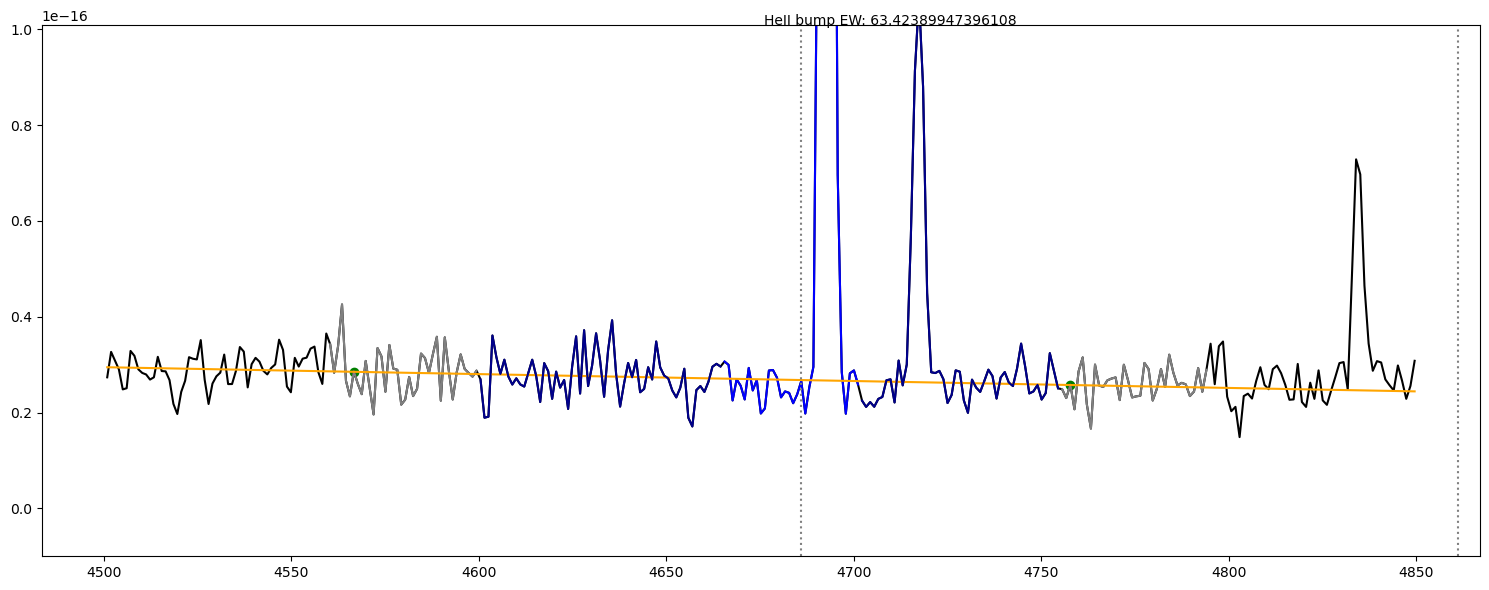

39
(4603,)


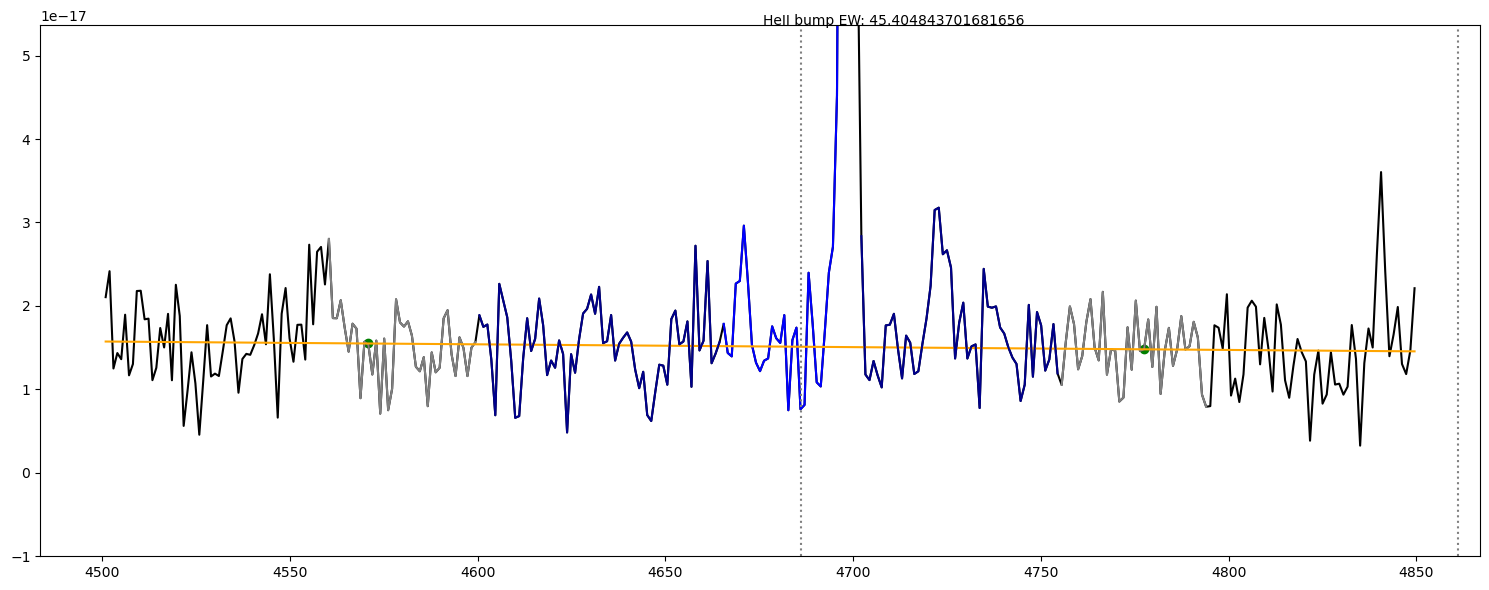

40
(4632,)


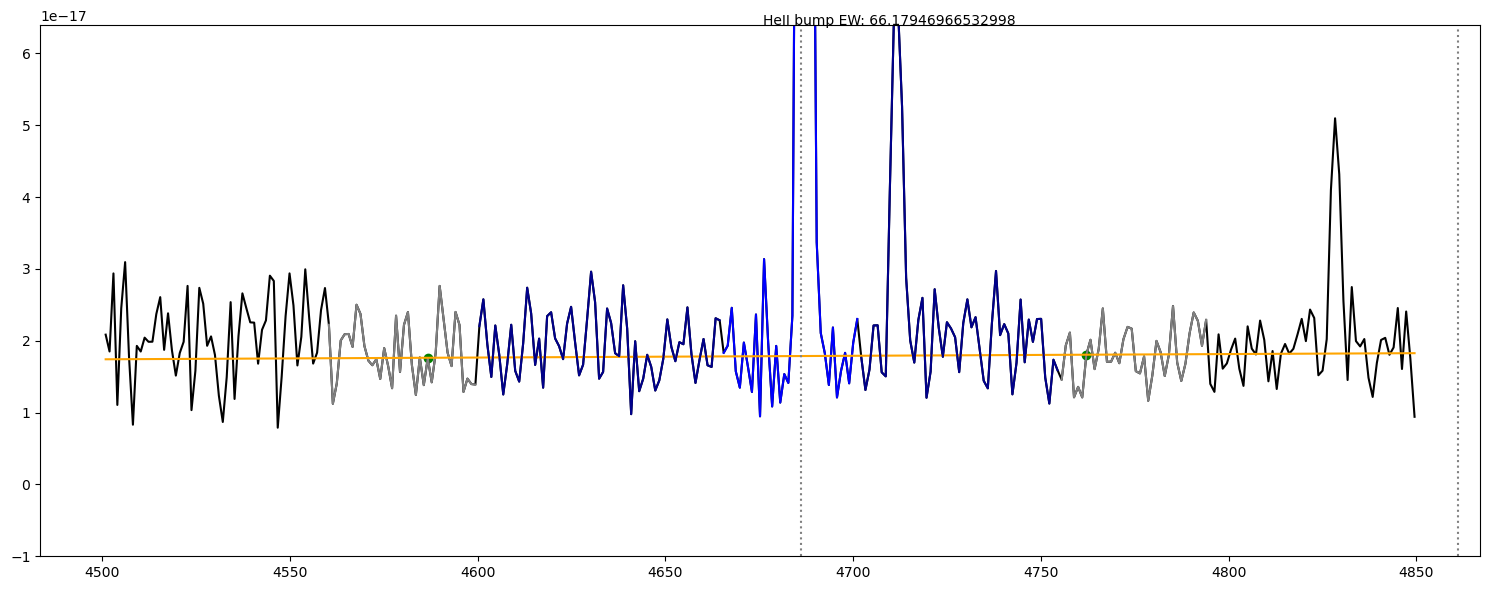

41
(4598,)


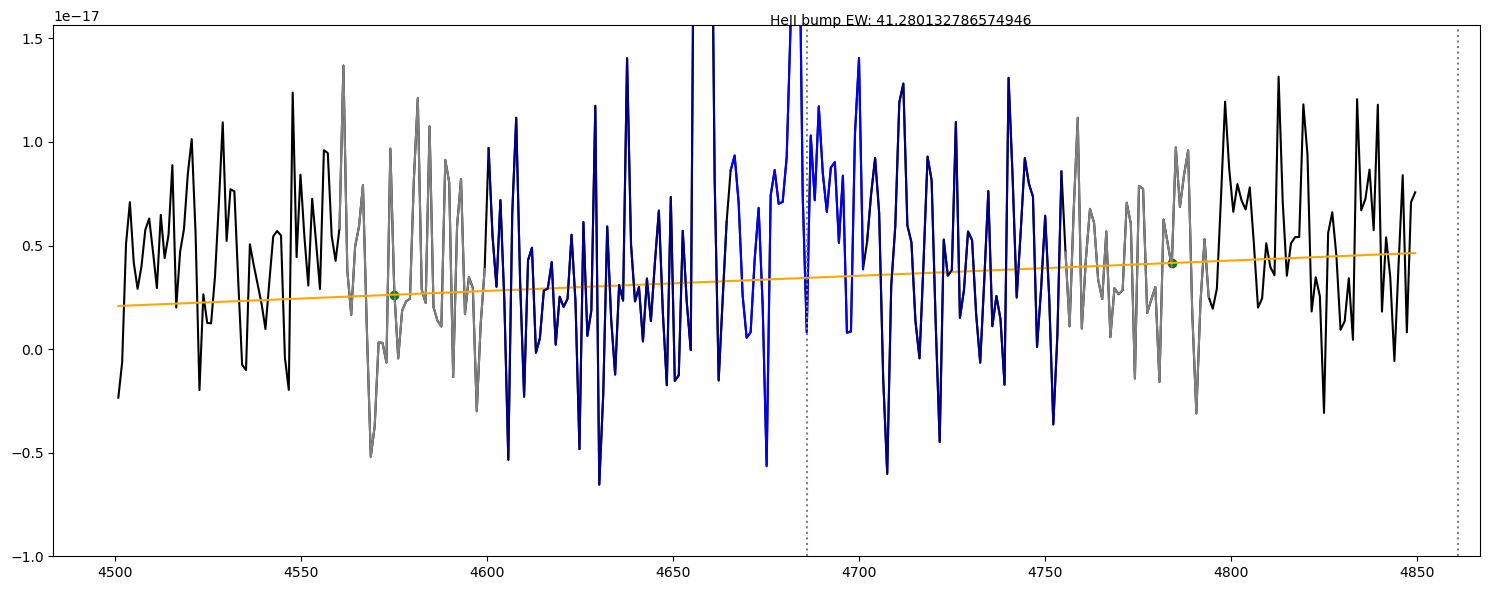

42
(4601,)


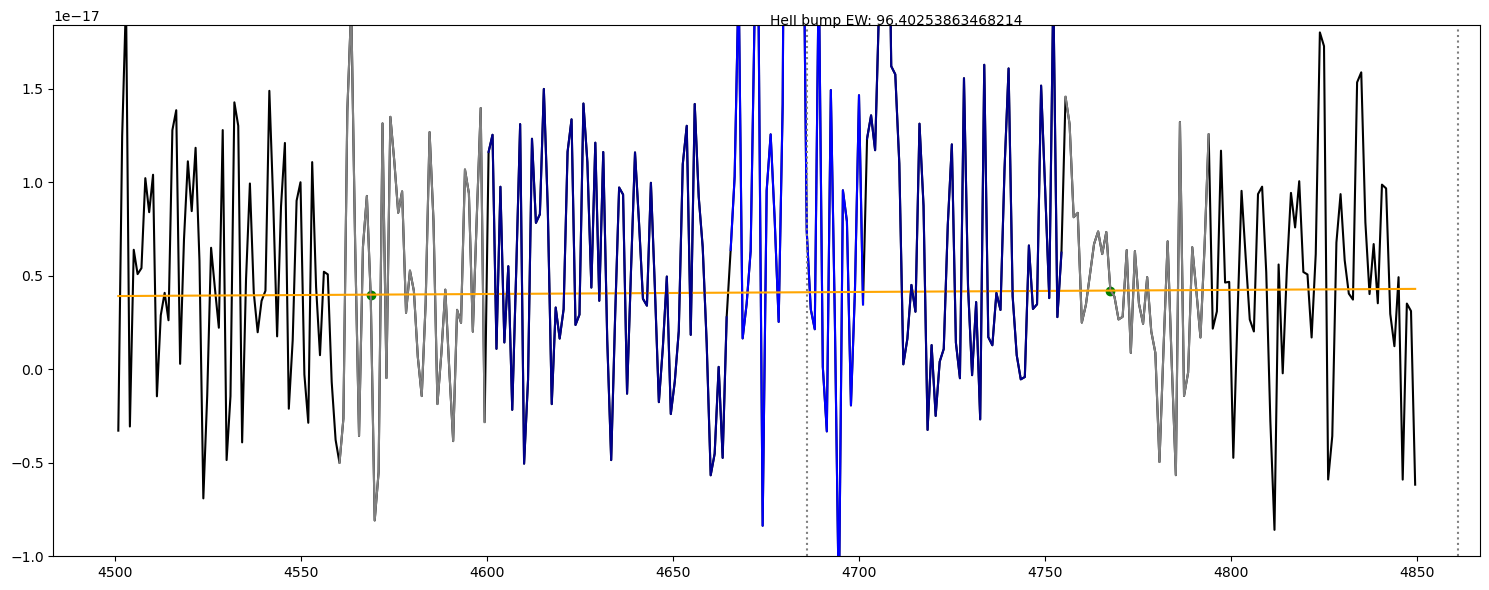

43
(4629,)


KeyboardInterrupt: 

In [ ]:

# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# # kay = [0]
# # k = np.array(kay)
# k = np.arange(0, len(VMS_WR_eBOSS), 1)

# #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# for i in k:    
#     print(i)
#     #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
#     max_flux_median = np.max([right_median[i], left_median[i]])
#     min_flux_median = np.min([right_median[i], left_median[i]])
    
#     if max_flux_median == right_median[i]:
#         max_wave_med = right_median_wav[i]
#         min_wave_med = left_median_wav[i]
#     elif max_flux_median == left_median[i]: ##### learned elif = else if ######
#         max_wave_med = left_median_wav[i]
#         min_wave_med = right_median_wav[i]
#     else: 
#         print('failed result:')
        
#     ########## New Method of finding base equation ###########
#     y_points = np.array([max_flux_median, min_flux_median])
#     x_points = np.array([max_wave_med, min_wave_med])
    
#     coefficients = np.polyfit(x_points, y_points, 1)
#     linear_func = np.poly1d(coefficients)

#     #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#     x = rest_frame_wavelengths_2[i]
#     y = rest_frame_flux_densities_2[i]

#     ### Measuring difference between bump flux and baseline equation flux 
#     WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
#     print(np.shape(WolfRayet_bump))

#     bump_wav = rest_frame_wavelengths_2[i][WolfRayet_bump[i]]
#     bump_flux = rest_frame_flux_densities_2[i][WolfRayet_bump[i]]
#     baseline_flux = linear_func(x)[WolfRayet_bump[i]]
#     delta_bump_flux = bump_flux - baseline_flux
#     norm_delta_flux = delta_bump_flux / baseline_flux
    
#     ##### Calculating Equivalent Width
#     EW = np.trapezoid(norm_delta_flux, bump_wav)      

#     ############ Creating axes #################
#     highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
#     yblue = rest_frame_flux_densities_2[i].copy()
#     yblue[~highlighted] = np.nan
    
#     ybump = rest_frame_flux_densities_2[i].copy()
#     ybump[~HeII_bump[i]] = np.nan

#     wr_bump = rest_frame_flux_densities_2[i].copy()
#     WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
#     wr_bump[~WolfRayet_bump] = np.nan
 
#     yspectra = rest_frame_flux_densities_2[i].copy()
#     yspectra[~between[i]] = np.nan

#     # baseline = equation.copy()
#     baseline = linear_func(x).copy()
#     baseline[~between[i]] = np.nan

#     plt.figure(figsize=(15,6))

#     ############### Plotting ###################
#     plt.plot(x, yspectra, color='black')
#     plt.plot(x, yblue, color='gray')
#     plt.plot(x, ybump, color='blue')
#     plt.plot(x, baseline, color='orange')
#     plt.plot(x, wr_bump, color ='darkblue')
#     plt.scatter(x_points, y_points, color='green')
#     # plt.plot(x, rest_frame_flux_density_errs_2[i])

#     plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
#     plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')

    
#     #yscale = log
#     # # plt.yscale('log')
#     median_flux = np.median(rest_frame_flux_densities_2[i])
#     lower_y_lim = median_flux * 0.008
#     upper_y_lim = median_flux * 5
#     plt.ylim(-1e-17, upper_y_lim)

#     plt.text(x=(4686-10), y=upper_y_lim, s=f'HeII bump EW: {VMS_WR_eBOSS['HeII_4686_BUMP_EW'][i]}')

#     plt.tight_layout() 
#     plt.show()


# print('success')

1
line SNR: 6.2681546
bump SNR: 6.1027164660428515


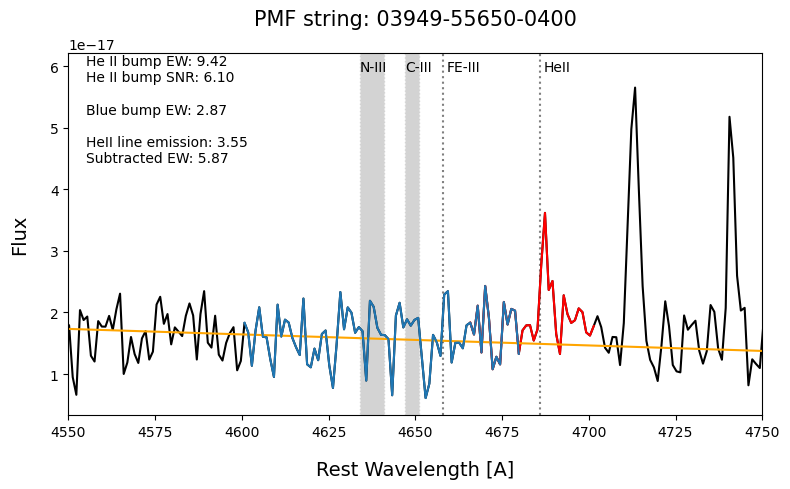

5
line SNR: 4.065353
bump SNR: 3.840020911406447


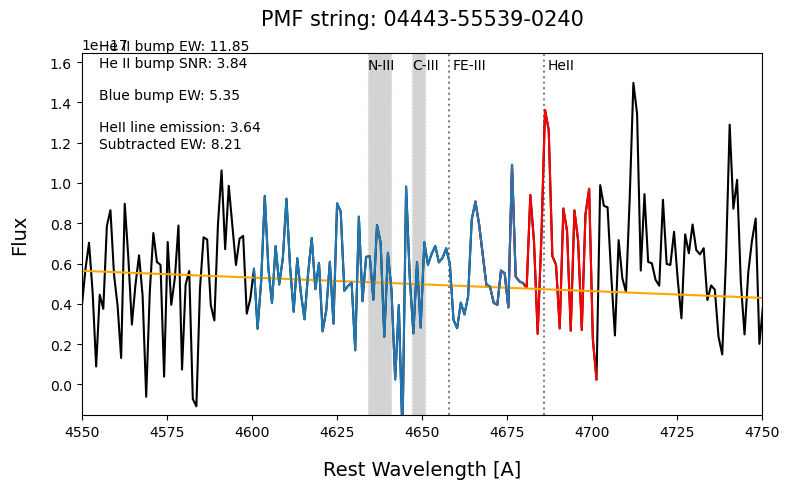

15
line SNR: 2.6447759
bump SNR: 4.327298740923439


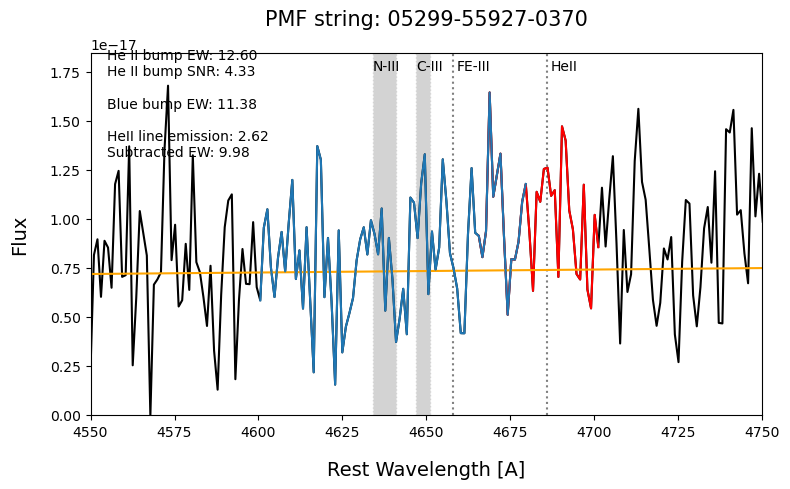

20
line SNR: 8.488351
bump SNR: 5.891342496884774


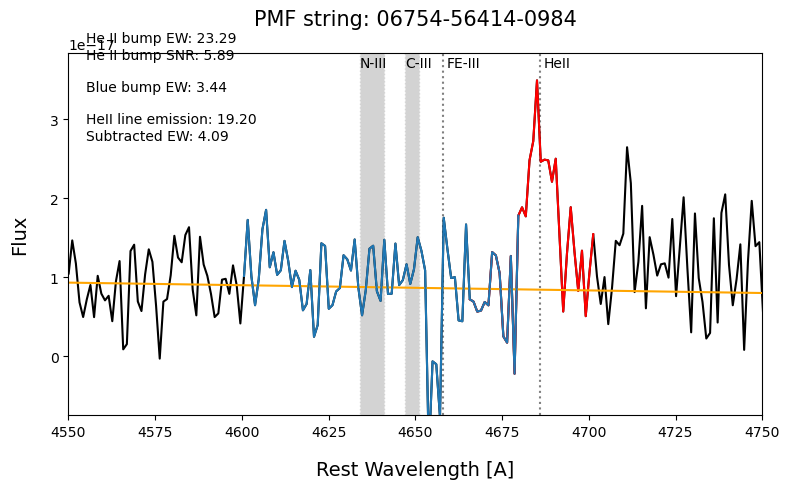

25
line SNR: 0.0
bump SNR: 3.8197742352724218


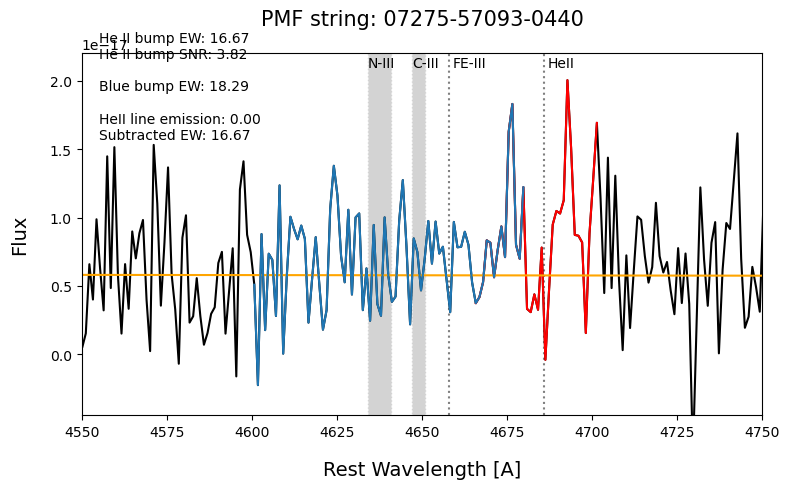

success


In [444]:
### N III emission lines in WR stars are often much weaker than He II bump in VMS

# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
kay = [1, 5, 15, 20, 25]
k = np.array(kay)
# k = np.arange(0, len(VMS_WR_eBOSS), 1)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    
    ###### Print Statements #######
    print(i)
    print(f'line SNR: {VMS_WR_eBOSS['HEII_4686_SNR'][i]}')
    print(f'bump SNR: {VMS_WR_eBOSS['HeII_4686_BUMP_EW_SNR'][i]}')

    x = rest_frame_wavelengths_2[i]
    y = rest_frame_flux_densities_2[i]

    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of WR blue bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
    bump_wav = rest_frame_wavelengths_2[i][WolfRayet_bump[i]]
    bump_flux = rest_frame_flux_densities_2[i][WolfRayet_bump[i]]
    baseline_flux = linear_func(x)[WolfRayet_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width
    EW = np.trapezoid(norm_delta_flux, bump_wav)      

    ############ Setting up different y axes #################
    highlighted = right_flat[i] | left_flat[i]      # "Flat" continuum portions
    
    ybump = rest_frame_flux_densities_2[i].copy()   # He II bump flux values 
    ybump[~HeII_bump[i]] = np.nan

    wr_bump = rest_frame_flux_densities_2[i].copy() # WR bump flux values
    wr_bump[~WolfRayet_bump[i]] = np.nan
    
    yspectra = rest_frame_flux_densities_2[i].copy()    # keeps spectra zoomed into HeII region
    yspectra[~between[i]] = np.nan

    baseline = linear_func(x).copy()                # continuum line
    baseline[~between[i]] = np.nan

    plt.figure(figsize=(8,5))

    ########### Graph Details #############
    plt.title(f'PMF string: {VMS_WR_eBOSS['PMF_STRING'][i]}', fontsize=15, pad=20)
    plt.xlabel('Rest Wavelength [A]', fontsize=14, labelpad=15)
    plt.ylabel('Flux', fontsize=14, labelpad=15)
    
    upper_y_lim = np.max(rest_frame_flux_densities_2[i][between[i]]) * 1.1
    lower_y_lim = np.min(rest_frame_flux_densities_2[i][between[i]]) * 0.6
    
    # median_flux = np.median(rest_frame_flux_densities_2[i])
    # lower_y_lim = median_flux * 0.05
    # upper_y_lim = median_flux * 20

    plt.text(4555, (upper_y_lim/1.4), f'He II bump EW: {VMS_WR_eBOSS['HeII_4686_BUMP_EW'][i]:.2f}\nHe II bump SNR: {VMS_WR_eBOSS['HeII_4686_BUMP_EW_SNR'][i]:.2f}\n\nBlue bump EW: {wolf_rayet_bump_EWs[i]:.2f}\n\nHeII line emission: {VMS_WR_eBOSS['HEII_4686_EW'][i]:.2f}\nSubtracted EW: {VMS_WR_eBOSS['HeII_4686_BUMP_SUBTRACT'][i]:.2f}')

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
    ##### spectral features
    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.text(4687, (upper_y_lim/1.05), 'HeII') #upper_y_lim - (upper_y_lim/85),
    plt.axvspan(4634, 4641, color='lightgrey',linestyle='dotted', label='N-III')
    plt.text(4634, (upper_y_lim/1.05), 'N-III') #upper_y_lim - (upper_y_lim/85),
    plt.axvline(4658, color='grey',linestyle='dotted', label='FE-III')
    plt.text(4659, (upper_y_lim/1.05), 'FE-III') #upper_y_lim - (upper_y_lim/85),
    plt.axvspan(4647, 4651, color='lightgrey',linestyle='dotted', label='C-III')
    plt.text(4647, (upper_y_lim/1.05), 'C-III') #upper_y_lim - (upper_y_lim/85),

    ##### spectra 
    plt.plot(x, yspectra, color='black') #, where='mid')
    plt.plot(x, ybump, color='red', label = 'He II bump') #, where='mid')
    plt.plot(x, baseline, color='orange') #, where='mid')
    plt.plot(x, wr_bump) #, where='mid')
    # median smoothing 
    # median_smooth_flux = median_filter(rest_frame_flux_densities_2[i], size=5, mode='reflect')
    # plt.scatter(x_points, y_points, color='green')
    # plt.step(x, median_smooth_flux, where='mid', color='red', label='smoothed data')

    plt.xlim(4550, 4750)
    plt.ylim(lower_y_lim, upper_y_lim)

    # path = os.path.join('standard_images', VMS_WR_eBOSS['PMF_STRING'][i])
    # file_path = path + '.png'
    # plt.savefig(file_path)

    plt.tight_layout() 
    plt.show()

    

print('success')

## Full Spectrum

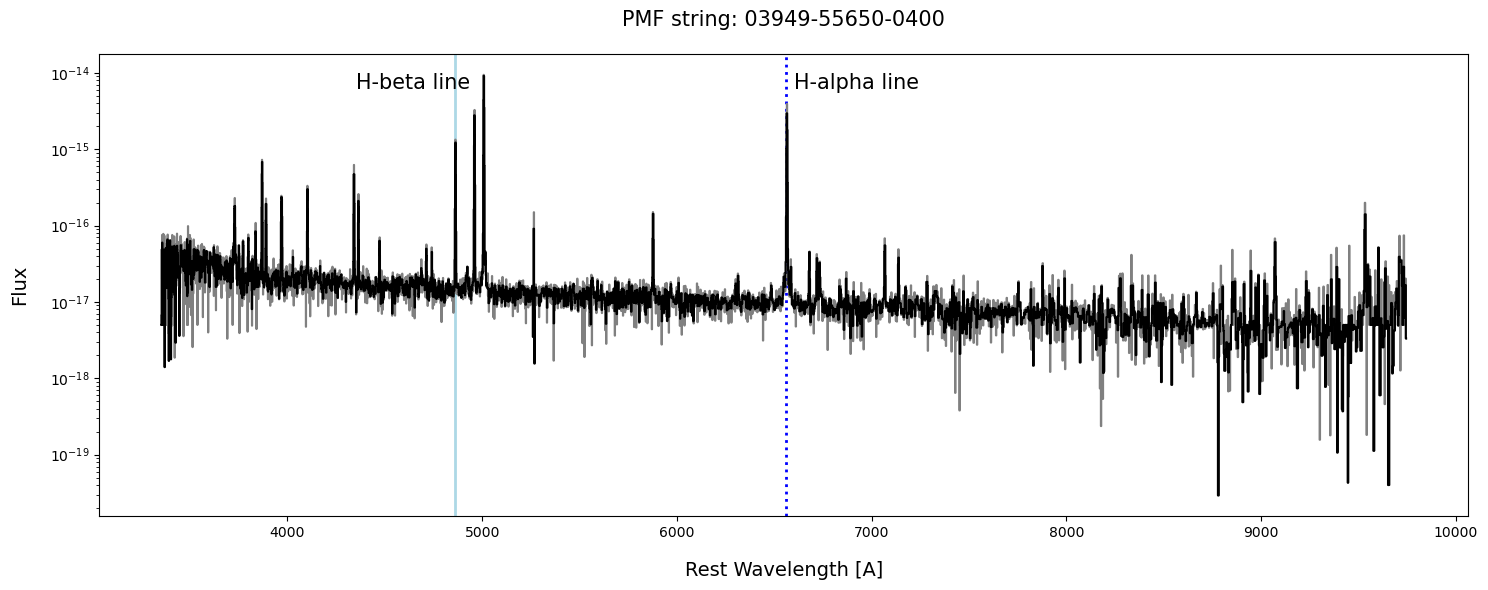

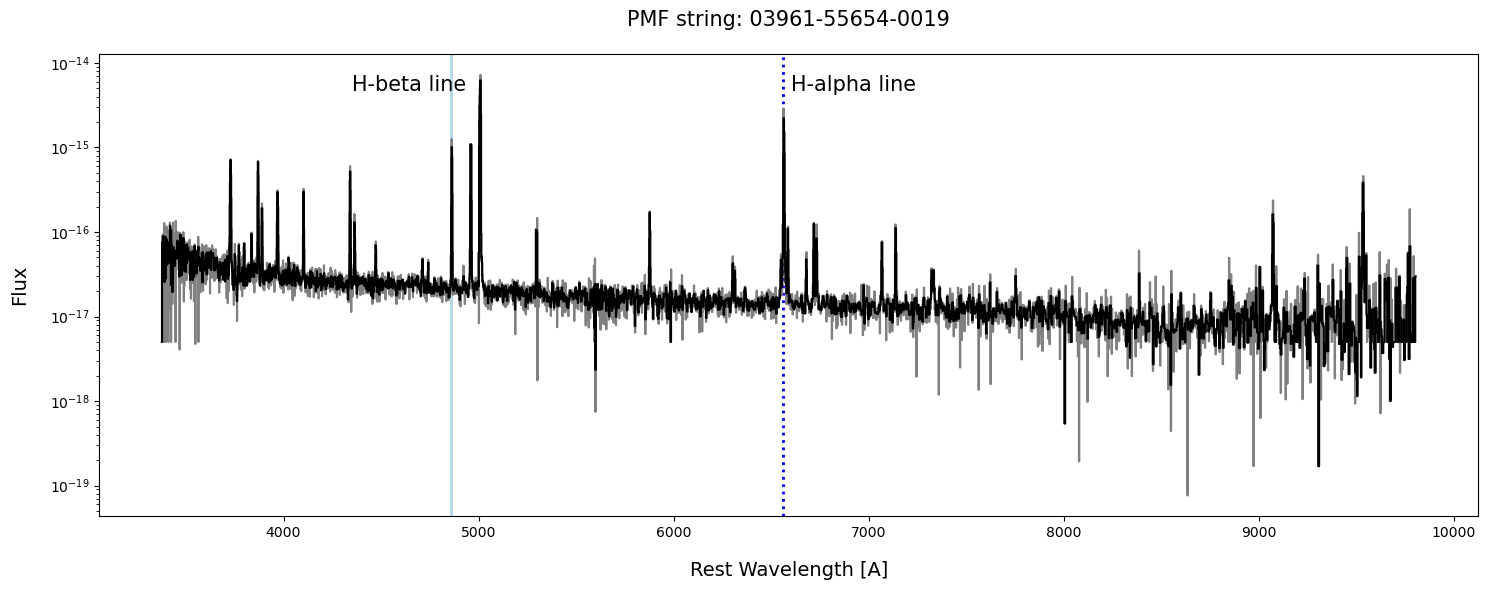

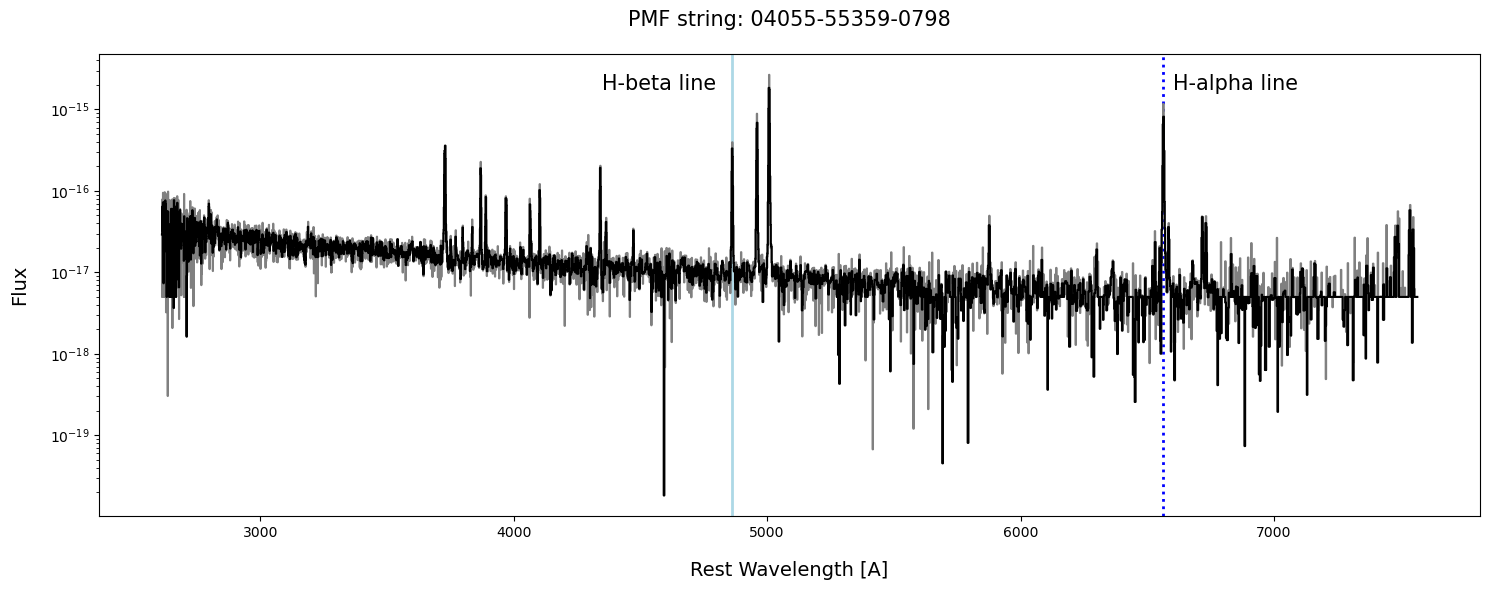

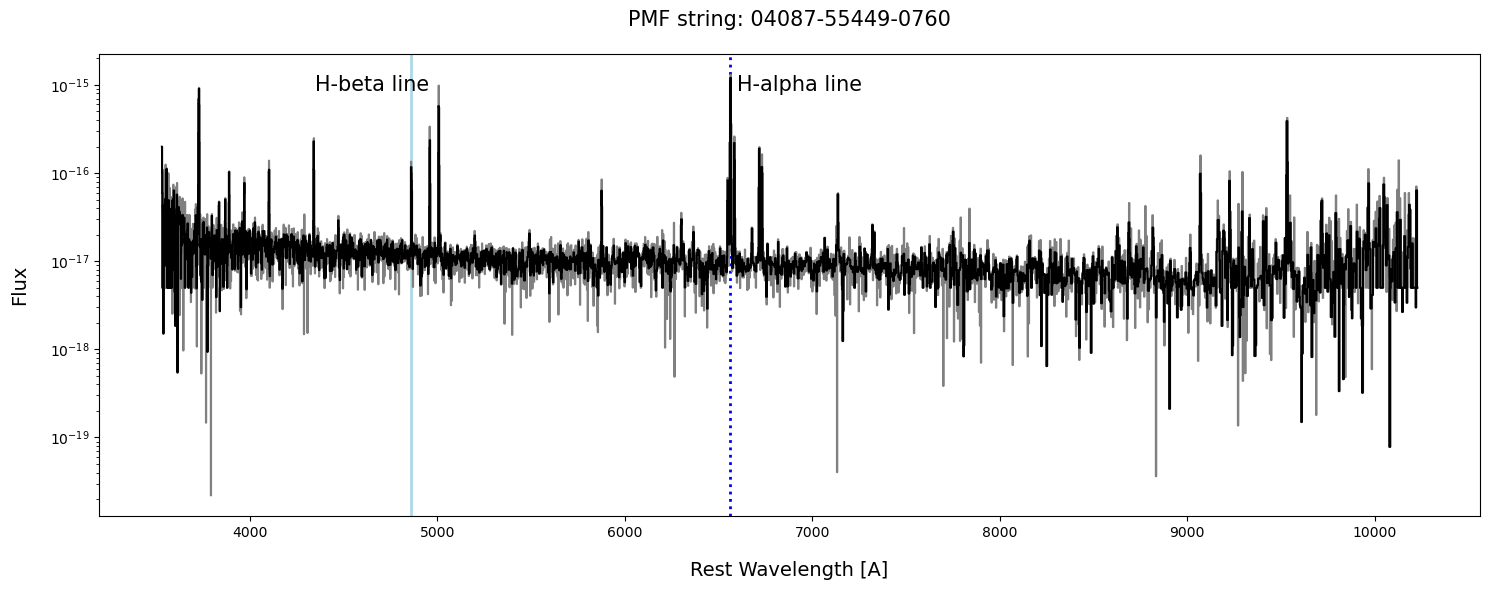

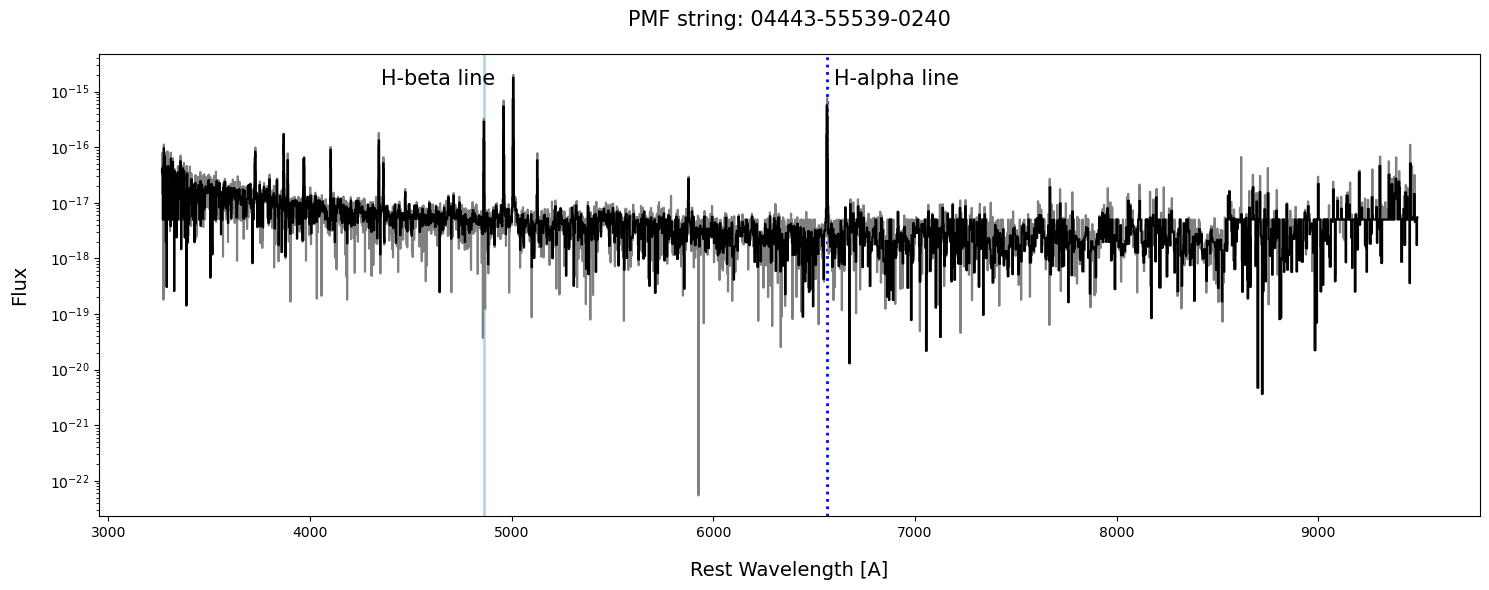

success


In [426]:
kay = [1, 2, 3, 4, 5]
k = np.array(kay)
# k = np.arange(0, len(VMS_WR_eBOSS), 1)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    

    x2 = rest_frame_wavelengths_2[i]
    y = rest_frame_flux_densities_2[i].copy()

    ######### Setting positive values due to log scale #################

    for flux_val in range(len(y)):
        if y[flux_val] < 0:
            y.flat[flux_val] = (0.5 * 10**-17) #### why this value and not lower? 
        else:
            pass 

    ############ Creating y axes for different features #################
    # ybump = rest_frame_flux_densities_2[i].copy()
    # ybump[~HeII_bump[i]] = np.nan

    ########## Median Smoothing
    median_smooth_flux = median_filter(rest_frame_flux_densities_2[i], size=3, mode='reflect')
    # ybump = median_smooth_flux.copy()
    # ybump[~HeII_bump[i]] = np.nan

    for flux_val in range(len(median_smooth_flux)):
            if median_smooth_flux[flux_val] < 0:
                median_smooth_flux.flat[flux_val] = (0.5 * 10**-17)
            else:
                pass 

    plt.figure(figsize=(15,6))

    ############  Messes with Spectrum Scale ############
    # linthresh = mad_std(y) 
    # plt.yscale('symlog', linthresh=linthresh, linscale=1)
    
    #################### For Error #####################
    upper_err = rest_frame_flux_densities_2[i] + rest_frame_flux_density_errs_2[i]
    lower_err = rest_frame_flux_densities_2[i] - rest_frame_flux_density_errs_2[i]

    ########## Scaling ############
    plt.yscale('log')
    upper_y_lim = np.max(rest_frame_flux_densities_2[i]) * 1.3
    lower_y_lim = np.min(rest_frame_flux_densities_2[i]) * 1
    
    # median_flux = np.median(rest_frame_flux_densities_2[i])
    # lower_y_lim = median_flux * 0.05
    # upper_y_lim = median_flux * 20
    # plt.ylim(1e-19, 1e-14)

    ############### ID Info #############
    plt.title(f'PMF string: {VMS_WR_eBOSS['PMF_STRING'][i]}', fontsize=15, pad=20)
    plt.xlabel('Rest Wavelength [A]', fontsize=14, labelpad=15)
    plt.ylabel('Flux', fontsize=14, labelpad=15)

    # ~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting ~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
    ######### Spectral Features ########
    #### He II bump
    # plt.plot(x2, ybump, color='red') ### Plots the He II bump feature
    # plt.axvline(4686, color='red',linestyle='dotted', label='HeII')
    # plt.text(4200, 0.25e-16, 'He II bump', fontsize=15)
    #### Emission Lines
    plt.axvline(4861, color='lightblue',linestyle='solid', linewidth=2, label='H-beta') # Plots the H beta emission line
    plt.text(4350, (upper_y_lim/2), 'H-beta line', fontsize=15)
    plt.axvline(6562, color='blue',linestyle='dotted', linewidth=2, label='H-alpha') # Plots the H alpha emission line
    plt.text(6601, (upper_y_lim/2), 'H-alpha line', fontsize=15)
    # plt.axvline(5801, color='green',linestyle='solid', linewidth=2, label='C-IV')
    #plt.text(5850, (upper_y_lim/2), 'C-IV line', fontsize=15)
    
    ####### Spectra #####
    #### plt.plot
    # plt.plot(x2, y, color='gray', alpha=0.3)                        #### raw spectra
    # plt.plot(x2, median_smooth_flux, color='black')
    # plt.fill_between(x2, upper_err, lower_err, color='gray')      ### error
    ### plt.step
    plt.step(x2, y, where='mid', color='gray')
    plt.step(x2, median_smooth_flux, where='mid', color='black', label='smoothed data')  #Median Smoothed spectra
    # plt.fill_between(x2, upper_err, lower_err, color='gray') 

    # plt.ylim(lower_y_lim, upper_y_lim)
    # plt.xlim(rest_frame_wavelengths_2, 10000)

    # ~~~~~~~~~~~~~~~~~~~~ Saving images ~~~~~~~~~~~~~~~~~~~~~~~
    # path = os.path.join('standard_images','full_spec', VMS_WR_eBOSS['PMF_STRING'][i])
    # file_path = path + '_01.png'
    # plt.savefig(file_path)

    plt.tight_layout()
    plt.show()


print('success')